#### temp eda discovered on kaggle documentation.
#### MAKE SURE TO DELETE UPON SUBMISSION

In [1]:
from IPython.display import display, HTML

display(HTML("<style>.container { width:100% !important; }</style>"))

# Import packages

In [2]:
import pandas as pd
import numpy as np
import math
import string

import matplotlib.pyplot as plt
import seaborn as sns

import plotly
import plotly.graph_objs as go
import plotly.express as px
from plotly.subplots import make_subplots

import datetime
from datetime import datetime

pd.set_option("display.max_columns", None)

import warnings

warnings.filterwarnings("ignore")

import math

import re
from collections import Counter

import glob
import math
import re
import time
import ast
from collections import Counter
from datetime import datetime

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from joblib import Parallel, delayed

import warnings

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)

# Functions

In [3]:
def describe_perc(dataset):
    return dataset.describe(
        include=["int64", "float64"],
        percentiles=[0.01, 0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]
    )

def clean_and_split(text):
    cleaned_text = [
        text_split.translate(
            str.maketrans("", "", string.punctuation.replace(",", ""))
        ) for text_split in text.split(sep="', '")
    ]
    return cleaned_text

def clean_and_split_dict(text):
    cleaned_text = text.strip("{}").replace(" ", "")
    pairs = cleaned_text.split(",")
    keys = [pair.split(":")[0].strip("'\"") for pair in pairs if ":" in pair]
    return keys


def make_histplot(feature, data, x_label, rotation=False):
    sns.histplot(data[feature])
    if rotation:
        plt.xticks(rotation=90)
    plt.title(f"Distribution of the feature {feature}")
    plt.ylabel("Number of games")
    plt.xlabel(x_label)
    plt.show()


def make_histplot_filtr(feature, data_list, x_labels, rotation=False):
    fig, axs = plt.subplots(2, 2, figsize=(12, 8))
    filtr = [
        "no restrictions",
        "over 40 reviews",
        "over 50 reviews",
        "over 100 reviews",
    ]
    for num, data in enumerate(data_list):
        ax = axs[num // 2, num % 2]
        sns.histplot(data[feature], ax=ax)
        if rotation:
            ax.set_xticklabels(ax.get_xticklabels(), rotation=90)

        ax.set_title(f"{filtr[num]}")

        if num < 2:
            ax.set_xlabel("")
            ax.set_xticklabels([])
            ax.set_xticks([])
        else:
            ax.set_xlabel(x_labels)

        if num % 2 > 0:
            ax.set_ylabel("")

        else:
            ax.set_ylabel("Number of games")

    fig.suptitle(f"Distribution of the feature {feature} \n", fontsize=16)

    plt.tight_layout()
    plt.show()


def make_countplot(feature, data, x_label, order, rotation=False):
    sns.countplot(x=feature, data=data, order=order)
    if rotation:
        plt.xticks(rotation=90)
    plt.title(f"Distribution of the feature {feature}")
    plt.ylabel("Number of games")
    plt.xlabel(x_label)
    plt.show()


def make_countplot_filtr(
    feature, data_list, x_labels, order, rotation=False, limit=False
):
    fig, axs = plt.subplots(2, 2, figsize=(12, 10))
    filtr = [
        "no restrictions",
        "over 40 reviews",
        "over 50 reviews",
        "over 100 reviews",
    ]
    for num, data in enumerate(data_list):
        ax = axs[num // 2, num % 2]
        sns.countplot(x=feature, data=data, order=order, ax=ax)

        if rotation:
            ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
        ax.set_title(f"{filtr[num]}")

        if num < 2:
            ax.set_xlabel("")
            ax.set_xticklabels([])
            ax.set_xticks([])
        else:
            ax.set_xlabel(x_labels)

        if num % 2 > 0:
            ax.set_ylabel("")

        else:
            ax.set_ylabel("Number of games")

        if limit:
            ax.set_xlim(-1, limit + 0.5)

    fig.suptitle(f"Distribution of the feature {feature} \n", fontsize=16)

    plt.tight_layout()
    plt.show()


def sort_range(ranges):
    def extract_range(estimated_owners):
        if estimated_owners == "0 - 0":
            return 0
        else:
            start, end = map(int, estimated_owners.split(" - "))
            return (start + end) / 2

    return sorted(ranges.unique(), key=extract_range)


def sort_prices(prices):
    def extract_price(price_group):
        if price_group == "Free":
            return 0
        if price_group.startswith("<"):
            return int(price_group.lstrip("< ").rstrip("$"))
        if price_group.startswith(">"):
            return int(price_group.lstrip("> ").rstrip("$")) + 1
        else:
            return int(price_group.rstrip("$"))

    return sorted(prices.unique(), key=extract_price)


def make_distplot(
    feature, data, x_label, rotation=False, x_min=-math.inf, x_max=math.inf
):
    sns.distplot(data[feature][(data[feature] > x_min) & (data[feature] < x_max)])
    if rotation:
        plt.xticks(rotation=90)
    plt.xlabel(x_label)
    plt.ylabel("Density")
    plt.title(f"Distribution of the feature {feature}")
    plt.show()


def make_distplot_filtr(
    feature, data_list, x_labels, rotation=False, x_min=-math.inf, x_max=math.inf
):
    fig, axs = plt.subplots(2, 2, figsize=(14, 10))
    filtr = [
        "no restrictions",
        "over 40 reviews",
        "over 50 reviews",
        "over 100 reviews",
    ]
    for num, data in enumerate(data_list):
        ax = axs[num // 2, num % 2]
        sns.distplot(
            data[feature][(data[feature] > x_min) & (data[feature] < x_max)], ax=ax
        )

        if rotation:
            ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
        ax.set_title(f"{filtr[num]}")

        if num < 2:
            ax.set_xlabel("")
            ax.set_xticklabels([])
            ax.set_xticks([])
        else:
            ax.set_xlabel(x_labels)

        if num % 2 > 0:
            ax.set_ylabel("")

        else:
            ax.set_ylabel("Number of games")

    fig.suptitle(f"Distribution of the feature {feature} \n", fontsize=16)

    plt.tight_layout()
    plt.show()


def make_barplot(feature, data, x_label, title, rotation=False, pre_counted=False):
    if pre_counted:
        plt.bar(data[feature], data["Count"])
    else:
        data = data[feature].explode().value_counts().reset_index()
        data = data[data[feature] != ""]
        plt.bar(data.iloc[:10, 0], data.iloc[:10, 1])

    if rotation:
        plt.xticks(rotation=90)
    plt.xlabel(x_label)
    plt.ylabel("Number of games")
    plt.title(f"Number of games by {title}")
    plt.show()


def make_barplot_filtr(feature, data_list, x_label, title, rotation=False):
    fig, axs = plt.subplots(2, 2, figsize=(12, 9))
    axs = axs.flatten()
    filtr = [
        "no restrictions",
        "over 40 reviews",
        "over 50 reviews",
        "over 100 reviews",
    ]

    for num, data in enumerate(data_list):
        data = data[feature].explode().value_counts().reset_index()
        axs[num].bar(data.iloc[:10, 0], data.iloc[:10, 1])
        if rotation:
            axs[num].set_xticklabels(data.iloc[:10, 0], rotation=90)

        axs[num].set_title(f"{filtr[num]}")
        axs[num].set_xlabel(x_label)

        if num % 2 > 0:
            axs[num].set_ylabel("")

        else:
            axs[num].set_ylabel("Number of games")

    fig.suptitle(f"Number of games by {title} \n", fontsize=16)

    plt.tight_layout()
    plt.show()


def countplot_many_features(data, feature, hue, order, rotation=False):
    data = data[data[feature].isin(order)]
    sns.countplot(data=data, x=feature, hue=hue, order=order)
    if rotation:
        plt.xticks(rotation=90)
    plt.xlabel(feature)
    plt.ylabel("Number of games")
    plt.title(f"Number of games by {feature}")
    plt.show()


# Corrects the date format in the Release_date column
def date_change_format(date):
    date_l = date.replace(",", "").split()
    num_entries = len(date_l)
    if num_entries == 1 or num_entries > 3:
        raise ValueError(date)
    elif num_entries == 2:
        return datetime.strptime(date, "%b %Y")
    else:
        return datetime.strptime(date, "%b %d, %Y")


def make_price_groups(price):
    for price_group in range(0, 80, 5):
        if float(price) == 0:
            return "Free"
        if price <= price_group:
            return "< " + str(price_group) + "$"

    return "> 80"


def make_set(feature, new_feature, df):
    df[new_feature] = [set(i) for i in df[feature]]

    all_text = list()
    for i in df[feature]:
        if "nan" not in str(i).lower():
            new_text_list = re.sub("[^a-z0-9,]", "", str(i).lower()).split(",")
            all_text.extend(new_text_list)

    dict_text = Counter(all_text)

    sorted_text = sorted(dict_text.items(), key=lambda item: item[1], reverse=True)
    sorted_text_df = pd.DataFrame(sorted_text[0:10], columns=[feature, "Count"])

    return df, sorted_text_df


def get_notes_type(note):
    sex_words = [
        "sex",
        "erotic",
        "nake",
        "nud",
        "underwear",
        "butt",
        "cloth",
        "fetish",
        "girl",
        "kiss",
        "masturb",
        "femal",
    ]
    violence_words = [
        "violen",
        "blood",
        "shoot",
        "kill",
        "abus",
        "gore",
        "weapons",
        "destr",
        "monster",
        "fight",
    ]
    mature_words = ["matur", "mild", "shock", "all ages", "child", "nsfw", "languag"]
    depression_words = ["suicid", "depression", "addiction", "smok", "alcoh"]

    sex_pattern = "(?:{})".format("|".join(sex_words))
    violence_pattern = "(?:{})".format("|".join(violence_words))
    mature_pattern = "(?:{})".format("|".join(mature_words))
    depression_pattern = "(?:{})".format("|".join(depression_words))
    none_pattern = "(?:{})".format("|".join(["none", "nan"]))

    patterns = [
        none_pattern,
        sex_pattern,
        violence_pattern,
        depression_pattern,
        mature_pattern,
    ]
    game_types = [
        "all ages",
        "sexual content",
        "violent content",
        "depression/suicide content",
        "mature content",
    ]

    new_note = str(note).lower()

    for pattern, game_type in zip(patterns, game_types):
        if bool(re.search(pattern, new_note)):
            return game_type


def plot_correlated_features(df, feature1, feature2):
    plt.scatter(df[feature1], df[feature2])
    plt.title(f"Correlated features \n{feature1} и {feature2}")
    plt.show()

# Look at the data

In [4]:
df = pd.read_csv("/kaggle/input/steam-games-dataset/games_march2025_cleaned.csv")

In [5]:
df.head()

,appid,name,release_date,required_age,price,dlc_count,detailed_description,about_the_game,short_description,reviews,header_image,website,support_url,support_email,windows,mac,linux,metacritic_score,metacritic_url,achievements,recommendations,notes,supported_languages,full_audio_languages,packages,developers,publishers,categories,genres,screenshots,movies,user_score,score_rank,positive,negative,estimated_owners,average_playtime_forever,average_playtime_2weeks,median_playtime_forever,median_playtime_2weeks,discount,peak_ccu,tags,pct_pos_total,num_reviews_total,pct_pos_recent,num_reviews_recent
0,730,Counter-Strike 2,2012-08-21,0,0.00,1,"For over two decades, Counter-Strike has offer...","For over two decades, Counter-Strike has offer...","For over two decades, Counter-Strike has offer...",NaN,https://shared.akamai.steamstatic.com/store_it...,http://counter-strike.net/,NaN,NaN,True,False,True,0,NaN,1,4401572,Includes intense violence and blood.,"['Czech', 'Danish', 'Dutch', 'English', 'Finni...","['English', 'Indonesian']","[{'title': 'Buy Counter-Strike 2', 'descriptio...",['Valve'],['Valve'],"['Multi-player', 'Cross-Platform Multiplayer',...","['Action', 'Free To Play']",['https://shared.akamai.steamstatic.com/store_...,['http://video.akamai.steamstatic.com/store_tr...,0,NaN,7480813,1135108,100000000 - 200000000,33189,879,5174,350,0,1212356,"{'FPS': 90857, 'Shooter': 65397, 'Multiplayer'...",86,8632939,82,96473
1,578080,PUBG: BATTLEGROUNDS,2017-12-21,0,0.00,0,"LAND, LOOT, SURVIVE! Play PUBG: BATTLEGROUNDS ...","LAND, LOOT, SURVIVE! Play PUBG: BATTLEGROUNDS ...",Play PUBG: BATTLEGROUNDS for free. Land on str...,NaN,https://shared.akamai.steamstatic.com/store_it...,https://www.pubg.com,https://support.pubg.com/hc/en-us,NaN,True,False,False,0,NaN,37,1732007,NaN,"['English', 'Korean', 'Simplified Chinese', 'F...",[],[],['PUBG Corporation'],"['KRAFTON, Inc.']","['Multi-player', 'PvP', 'Online PvP', 'Stats',...","['Action', 'Adventure', 'Massively Multiplayer...",['https://shared.akamai.steamstatic.com/store_...,[],0,NaN,1487960,1024436,50000000 - 100000000,0,0,0,0,0,616738,"{'Survival': 14838, 'Shooter': 12727, 'Battle ...",59,2513842,68,16720
2,570,Dota 2,2013-07-09,0,0.00,2,"The most-played game on Steam. Every day, mill...","The most-played game on Steam. Every day, mill...","Every day, millions of players worldwide enter...",“A modern multiplayer masterpiece.” 9.5/10 – D...,https://shared.akamai.steamstatic.com/store_it...,http://www.dota2.com/,NaN,NaN,True,True,True,90,https://www.metacritic.com/game/pc/dota-2?ftag...,0,14337,"Dota 2 includes fantasy violence, use of alcoh...","['Bulgarian', 'Czech', 'Danish', 'Dutch', 'Eng...","['English', 'Korean', 'Simplified Chinese', 'V...","[{'title': 'Buy Dota 2', 'description': '', 's...",['Valve'],['Valve'],"['Multi-player', 'Co-op', 'Steam Trading Cards...","['Action', 'Strategy', 'Free To Play']",['https://shared.akamai.steamstatic.com/store_...,['http://video.akamai.steamstatic.com/store_tr...,0,NaN,1998462,451338,200000000 - 500000000,43031,1536,898,892,0,555977,"{'Free to Play': 59933, 'MOBA': 20158, 'Multip...",81,2452595,80,29366
3,271590,Grand Theft Auto V Legacy,2015-04-13,17,0.00,0,"When a young street hustler, a retired bank ro...","When a young street hustler, a retired bank ro...",Grand Theft Auto V for PC offers players the o...,NaN,https://shared.akamai.steamstatic.com/store_it...,https://www.rockstargames.com/V/,https://support.rockstargames.com,NaN,True,False,False,96,https://www.metacritic.com/game/pc/grand-theft...,77,1803063,NaN,"['English', 'French', 'Italian', 'German', 'Sp...","['English', 'Spanish - Latin America']","[{'title': 'Buy Shark Cash Cards', 'descriptio...",['Rockstar North'],['Rockstar Games'],"['Single-player', 'Multi-player', 'PvP', 'Onli...","['Action', 'Adventure']",['https://shared.akamai.steamstatic.com/store_...,['http://video.akamai.steamstatic.com/store_tr...,0,NaN,1719950,250012,50000000 - 100000000,19323,771,7101,74,0,117698,"{'Open World':

In [6]:
columns_to_process = [
    "supported_languages", "full_audio_languages", "categories",
    "genres", "developers", "publishers", "tags"
]

for col in columns_to_process[:-1]:
    df[col] = df[col].apply(clean_and_split)

df["tags"] = df["tags"].apply(clean_and_split_dict)

In [7]:
df[columns_to_process]

,supported_languages,full_audio_languages,categories,genres,developers,publishers,tags
0,"[Czech, Danish, Dutch, English, Finnish, Frenc...","[English, Indonesian]","[Multiplayer, CrossPlatform Multiplayer, Steam...","[Action, Free To Play]",[Valve],[Valve],"[FPS, Shooter, Multiplayer, Competitive, Actio..."
1,"[English, Korean, Simplified Chinese, French, ...",[],"[Multiplayer, PvP, Online PvP, Stats, Remote P...","[Action, Adventure, Massively Multiplayer, Fre...",[PUBG Corporation],"[KRAFTON, Inc]","[Survival, Shooter, BattleRoyale, Multiplayer,..."
2,"[Bulgarian, Czech, Danish, Dutch, English, Fin...","[English, Korean, Simplified Chinese, Vietnamese]","[Multiplayer, Coop, Steam Trading Cards, Steam...","[Action, Strategy, Free To Play]",[Valve],[Valve],"[FreetoPlay, MOBA, Multiplayer, Strategy, e-sp..."
3,"[English, French, Italian, German, Spanish Sp...","[English, Spanish Latin America]","[Singleplayer, Multiplayer, PvP, Online PvP, C...","[Action, Adventure]",[Rockstar North],[Rockstar Games],"[OpenWorld, Action, Multiplayer, Crime, Automo..."
4,"[English, French, Italian, German, Spanish Sp...","[English, French, Italian, German, Spanish Sp...","[Singleplayer, Multiplayer, PvP, Online PvP, C...",[Action],[Ubisoft Montreal],[Ubisoft],"[FPS, PvP, e-sports, Multiplayer, Tactical, Sh..."
...,...,...,...,...,...,...,...
89613,[English],[],"[Singleplayer, Steam Achievements, Stats, Stea...","[Indie, Early Access]",[TheBean],[TheBean],"[2DPlatformer, Runner, Platformer, 2D, Top-Dow..."
89614,"[English, Turkish]","[English, Turkish]","[Singleplayer, Family Sharing]","[Action, Adventure, Indie, Strategy]",[Pyramid Games],[Orion Asistan Hizmetleri AS],"[Action, Adventure, Indie, Strategy]"
89615,[English],[],"[Singleplayer, Family Sharing]","[Indie, Early Access]",[Prime2Gold],[Prime2Gold],"[Indie, EarlyAccess]"
89616,"[English, Simplified Chinese, French, German, ...","[English, Italian]","[Singleplayer, Multiplayer, PvP, Online PvP, C...","[Adventure, RPG, Simulation, Strategy]",[XuJie],[XuJie],"[RPG, Action-Adventure, Strategy, Simulation, ..."


In [8]:
df.shape

(89618, 47)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 89618 entries, 0 to 89617
Data columns (total 47 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   appid                     89618 non-null  int64  
 1   name                      89618 non-null  object 
 2   release_date              89618 non-null  object 
 3   required_age              89618 non-null  int64  
 4   price                     89618 non-null  float64
 5   dlc_count                 89618 non-null  int64  
 6   detailed_description      89421 non-null  object 
 7   about_the_game            89398 non-null  object 
 8   short_description         89498 non-null  object 
 9   reviews                   10401 non-null  object 
 10  header_image              89618 non-null  object 
 11  website                   41114 non-null  object 
 12  support_url               44110 non-null  object 
 13  support_email             78798 non-null  object 
 14  window

## Features description

`appid` - Steam application identifier  
`name` - game name  
`release_date` - game release date  
`required_age` - required age
`price` - current price in USD  
`dlc_count` - number of add-ons for the game
`detailed_description` - game detailed description  
`about_the_game` - game description  
`short_description` - game short description  
`reviews` - reviews  
`header_image` - header image  
`website` - game website  
`support_url` - support link for the game  
`support_email` - support email for the game  
`windows` - available on Windows  
`mac` - available on Mac  
`linux` - available on Linux  
`metacritic_score` - score on Metacritic  
`metacritic_url` - link to Metacritic  
`achievements` - number of achievements in the game  
`recommendations` - number of recommendations  
`notes` - warnings about the game (e.g., warnings about violence in the game and that it is not intended for young children)  
`supported_languages` - list of supported languages  
`full_audio_languages` - list of supported audio languages  
`packages` - collection of games, DLC, or other items sold as a single product   
`developers` - comma separated list of the game developers.  
`publishers` - list of publishers of the game, separated by commas.  
`categories` - comma separated list of categories  
`genres` - comma separated list of genres  
`screenshots` - game footage  
`movies` - game videos  
`user_score` - user score  
`score_rank` - rating of the game based on user reviews  
`positive` - number of positive reviews  
`negative` - number of negative reviews  
`estimated_owners` - number of users who have purchased the game  
`average_playtime_forever` - average playtime since March 2009. In minutes  
`average_playtime_2weeks` - average playtime over the last two weeks. In minutes  
`median_playtime_forever` - median playtime since March 2009. In minutes  
`median_playtime_2weeks` - median playtime over the last two weeks. In minutes  
`discount` - discount percentage  
`peak_ccu` - peak number of users (CCU) for yesterday  
`tags` - comma separated list of game tags  
`pct_pos_total` - percentage of positive reviews over all time (of total reviews)  
`num_reviews_total` - total number of reviews over time  
`pct_pos_recent` - percentage of positive reviews in the last 30 days  
`num_reviews_recent` - total number of reviews in the last 30 days  

## Descriptive statistics

In [10]:
# for categorical features
df.drop(columns=columns_to_process).describe(include=["object", "bool"])

,name,release_date,detailed_description,about_the_game,short_description,reviews,header_image,website,support_url,support_email,windows,mac,linux,metacritic_url,notes,packages,screenshots,movies,estimated_owners
count,89618,89618,89421,89398,89498,10401,89618,41114,44110,78798,89618,89618,89618,3547,16643,89618,89618,89618,89618
unique,88899,4459,89075,89040,88586,10291,89587,33321,29309,48174,2,2,2,3507,13946,75740,89482,87183,15
top,Alone,2024-10-31,Help the beautiful girls to immerse themselves...,Help the beautiful girls to immerse themselves...,Find the objects that are hidden on the map.,“ ” Read more on PC Gamer,https://shared.akamai.steamstatic.com/store_it...,https://www.facebook.com/8FloorGames/,https://www.facebook.com/8FloorGames,info@bigfishgames.com,True,False,False,https://www.metacritic.com/game/pc/shadow-of-t...,This Game may contain content not appropriate ...,[],[],[],0 - 20000
freq,6,141,58,58,50,21,5,247,270,314,89588,72180,76991,5,135,13819,106,2411,59320


In [11]:
# for numerical features
describe_perc(df)

,appid,required_age,price,dlc_count,metacritic_score,achievements,recommendations,user_score,score_rank,positive,negative,average_playtime_forever,average_playtime_2weeks,median_playtime_forever,median_playtime_2weeks,discount,peak_ccu,pct_pos_total,num_reviews_total,pct_pos_recent,num_reviews_recent
count,8.961800e+04,89618.000000,89618.000000,89618.000000,89618.000000,89618.000000,8.961800e+04,89618.000000,39.000000,8.961800e+04,8.961800e+04,8.961800e+04,89618.000000,8.961800e+04,89618.000000,89618.000000,8.961800e+04,89618.000000,8.961800e+04,89618.000000,89618.000000
mean,1.656904e+06,0.183624,7.309623,0.595583,2.903245,20.552333,1.009401e+03,0.032817,99.128205,1.269896e+03,2.098026e+02,1.149119e+02,5.032694,1.147559e+02,5.301814,4.558627,9.833994e+01,45.352418,1.315490e+03,5.231639,15.584581
std,9.168390e+05,1.725594,13.331073,15.351920,14.445358,163.562418,2.204815e+04,1.615149,0.695076,3.181441e+04,6.114314e+03,6.814748e+03,181.100334,8.806711e+03,189.591095,16.538036,5.717544e+03,40.685695,3.542370e+04,22.335358,444.277307
min,2.000000e+01,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,98.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000,0.000000e+00,-1.000000,-1.000000e+00,-1.000000,-1.000000
1%,2.226719e+05,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,98.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000,0.000000e+00,-1.000000,-1.000000e+00,-1.000000,-1.000000
5%,3.550585e+05,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,98.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000,0.000000e+00,-1.000000,-1.000000e+00,-1.000000,-1.000000
10%,4.880770e+05,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,98.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000,0.000000e+00,-1.000000,-1.000000e+00,-1.000000,-1.000000
25%,8.550525e+05,0.000000,0.990000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,99.000000,1.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000,0.000000e+00,-1.000000,-1.000000e+00,-1.000000,-1.000000
50%,1.524730e+06,0.000000,4.990000,0.000000,0.000000,5.000000,0.000000e+00,0.000000,99.000000,1.000000e+01,2.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000,0.000000e+00,60.000000,1.500000e+01,-1.000000,-1.000000
75%,2.430852e+06,0.000000,9.990000,0.000000,0.000000,20.000000,0.000000e+00,0.000000,100.000000,5.800000e+01,1.700000e+01,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000,0.000000e+00,84.000000,8.100000e+01,-1.000000,-1.000000


**Irrelevant features (can be deleted):**
- **User score, Score rank** - values are only available for a few tens games
- **Average playtime two weeks, Median playtime two weeks, Peak CCU, pct_pos_recent, num_reviews_recent** - fast becoming outdated features
- **Header image, Website, Support url, Support email, Metacritic url, Screenshots, Movies** - links/addresses

In [12]:
df = df.drop(
    columns=[
        "user_score",
        "score_rank",
        "average_playtime_2weeks",
        "median_playtime_2weeks",
        "peak_ccu",
        "header_image",
        "website",
        "support_url",
        "support_email",
        "metacritic_url",
        "screenshots",
        "movies",
    ]
)

# Single factor analysis

### Release_date distribution plot

In [13]:
df["release_date"] = pd.to_datetime(df["release_date"])

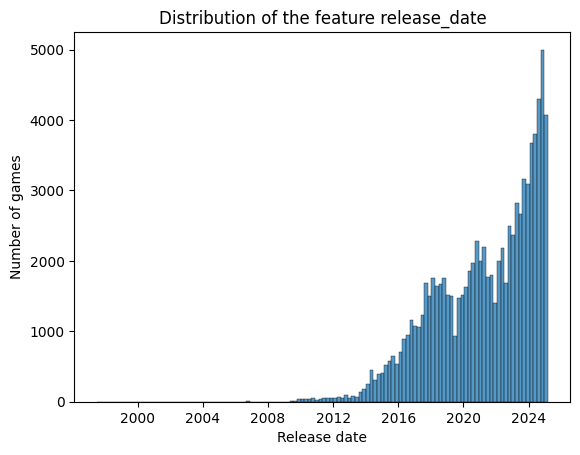

In [14]:
make_histplot("release_date", df, "Release date")

**Most of the games in the sample are games released after 2014**

### Estimated owners

In [15]:
value_counts = df["estimated_owners"].value_counts(normalize=True)
value_counts[sort_range(value_counts.index)]

estimated_owners
0 - 0                    0.093932
0 - 20000                0.661921
20000 - 50000            0.108047
50000 - 100000           0.050793
100000 - 200000          0.033531
200000 - 500000          0.027550
500000 - 1000000         0.011582
1000000 - 2000000        0.006405
2000000 - 5000000        0.004162
5000000 - 10000000       0.001205
10000000 - 20000000      0.000469
20000000 - 50000000      0.000268
50000000 - 100000000     0.000112
100000000 - 200000000    0.000011
200000000 - 500000000    0.000011
Name: proportion, dtype: float64

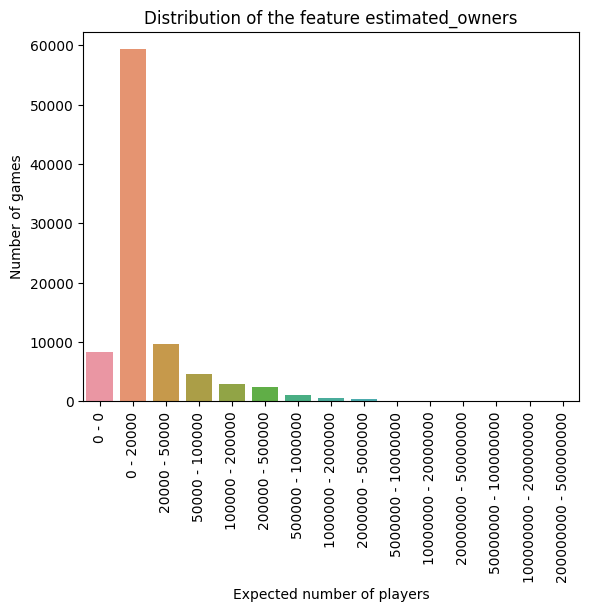

In [16]:
make_countplot(
    "estimated_owners",
    df,
    "Expected number of players",
    sort_range(df["estimated_owners"]),
    rotation=True,
)

**The sample mainly includes unpopular games with a small number of players**

### Required age

In [17]:
df["required_age"].value_counts().sort_index()

required_age
-1         1
 0     88589
 1         2
 3         7
 6         4
 7         5
 10       27
 12       21
 13      155
 14        1
 15        3
 16       31
 17      618
 18      152
 20        1
 21        1
Name: count, dtype: int64

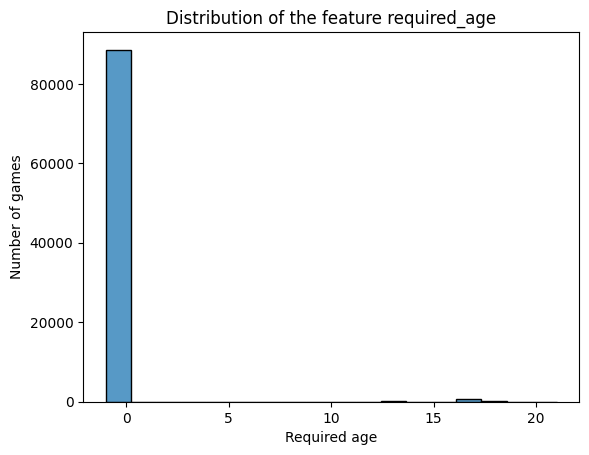

In [18]:
make_histplot("required_age", df, "Required age")

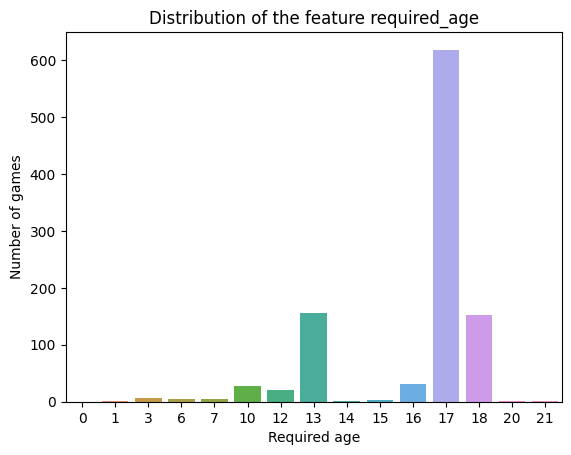

In [19]:
make_countplot(
    "required_age",
    df[df["required_age"] != 0],
    "Required age",
    order=sorted(df["required_age"].unique())[1:],
)

**Most age-restricted games have an age limit of 17/18.**

### Price

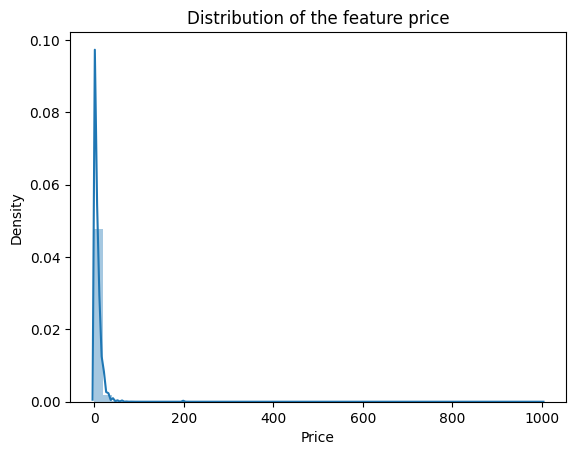

In [20]:
make_distplot("price", df, "Price")

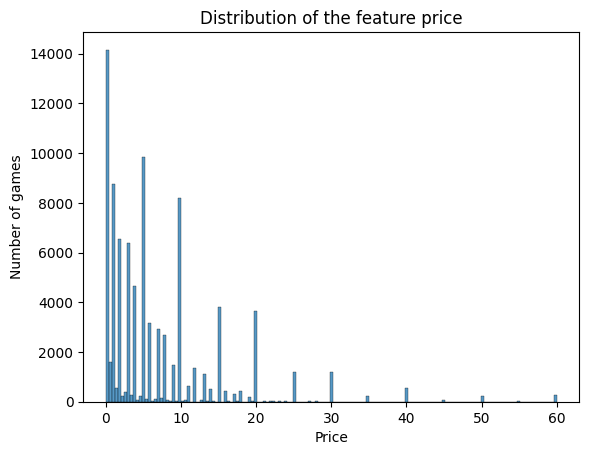

In [21]:
make_histplot("price", df.loc[(df["price"] < 60)], "Price")

**Clearly see groups of games by cost:**
- free
- about 5 dollars
- about 10 dollars
- about 15 dollars
- about 20 dollars
- about 25 dollars
- about 30 dollars
etc.

In [22]:
df["price_group"] = [make_price_groups(price) for price in df["price"]]

In [23]:
df[["price", "price_group"]]

,price,price_group
0,0.00,Free
1,0.00,Free
2,0.00,Free
3,0.00,Free
4,3.99,< 5$
...,...,...
89613,3.99,< 5$
89614,10.00,< 10$
89615,1.99,< 5$
89616,29.99,< 30$


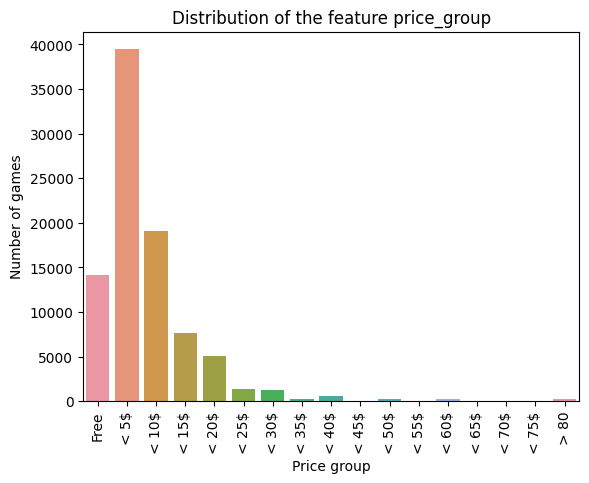

In [24]:
make_countplot(
    "price_group", df, "Price group", sort_prices(df["price_group"]), rotation=True
)

**Most of the sample includes inexpensive games under $15**

### DLC count
additional paid in-game content

In [25]:
df["dlc_count"].value_counts(normalize=True).sort_index().head(10)

dlc_count
0    0.841215
1    0.100504
2    0.025051
3    0.010288
4    0.005423
5    0.003627
6    0.002299
7    0.001651
8    0.001372
9    0.001071
Name: proportion, dtype: float64

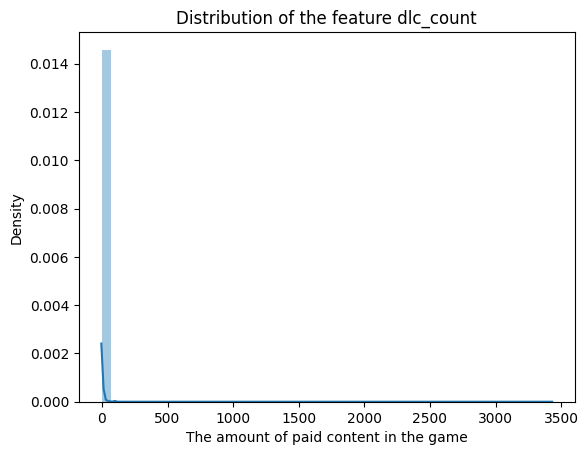

In [26]:
make_distplot("dlc_count", df, "The amount of paid content in the game")

**For most games, there is no additional paid content. Let's look at the distribution chart for games with paid content separately:**

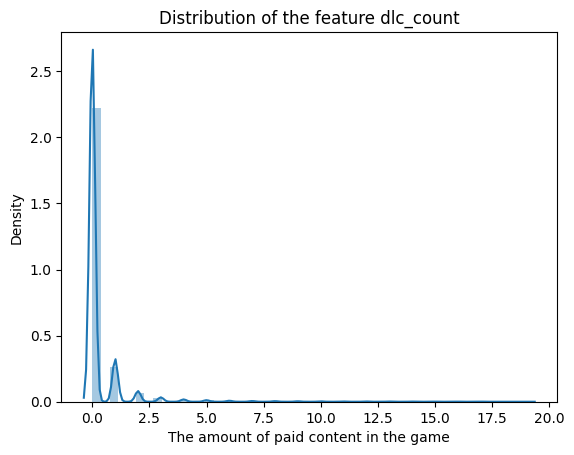

In [27]:
make_distplot(
    "dlc_count", df, "The amount of paid content in the game", x_min=-0.1, x_max=20
)

### Supported languages

In [28]:
df["supported_languages"]

0        [Czech, Danish, Dutch, English, Finnish, Frenc...
1        [English, Korean, Simplified Chinese, French, ...
2        [Bulgarian, Czech, Danish, Dutch, English, Fin...
3        [English, French, Italian, German, Spanish  Sp...
4        [English, French, Italian, German, Spanish  Sp...
                               ...                        
89613                                            [English]
89614                                   [English, Turkish]
89615                                            [English]
89616    [English, Simplified Chinese, French, German, ...
89617                                            [English]
Name: supported_languages, Length: 89618, dtype: object

In [29]:
df["num_supported_languages"] = [len(list(i)) for i in df["supported_languages"]]

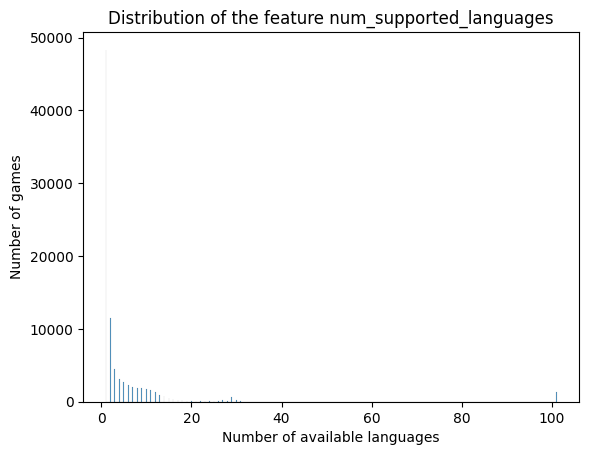

In [30]:
make_histplot("num_supported_languages", df, "Number of available languages")

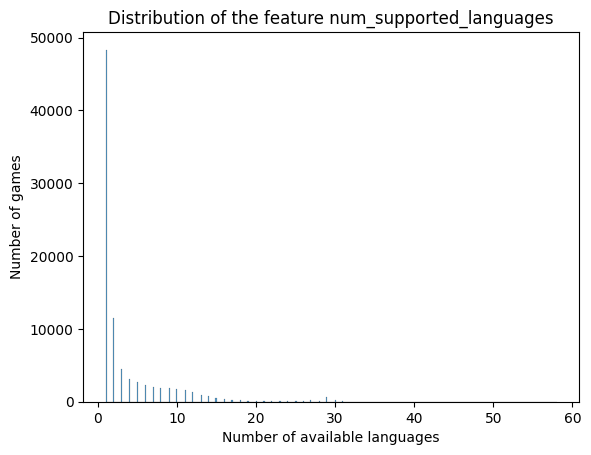

In [31]:
make_histplot(
    "num_supported_languages",
    df[df["num_supported_languages"] < 60],
    "Number of available languages",
)

**Mainly the game translation is available in less than 5 languages**

In [32]:
df, sorted_text_lang_df = make_set("supported_languages", "text_languages_set", df)

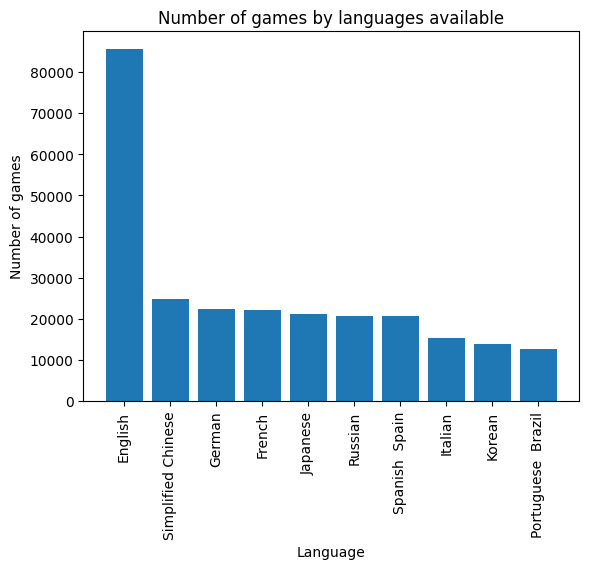

In [33]:
make_barplot(
    "supported_languages", df, "Language", "languages available", rotation=True
)

### Full audio languages

In [34]:
df["num_full_audio_languages"] = [len(list(i)) for i in df["full_audio_languages"]]

In [35]:
df["num_full_audio_languages"].value_counts(normalize=True).sort_index().head(10)

num_full_audio_languages
1     0.814078
2     0.119362
3     0.017876
4     0.006037
5     0.004396
6     0.004441
7     0.003314
8     0.002522
9     0.002511
10    0.002287
Name: proportion, dtype: float64

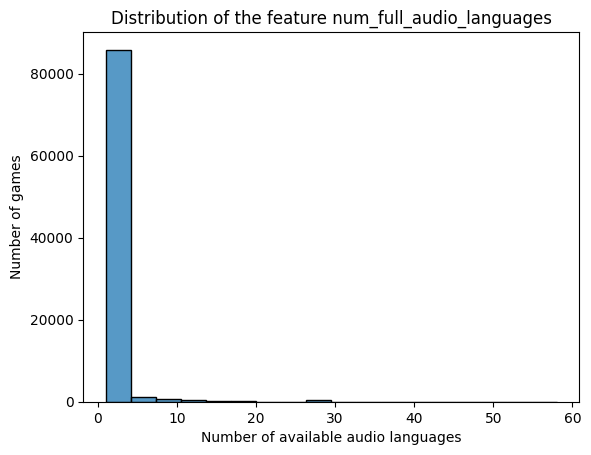

In [36]:
make_histplot(
    "num_full_audio_languages",
    df[df["num_full_audio_languages"] < 60],
    "Number of available audio languages",
)

**Most games support audio in two or three languages**

In [37]:
df, sorted_audio_lang_df = make_set("full_audio_languages", "audio_languages_set", df)

In [38]:
df.explode("audio_languages_set")

,appid,name,release_date,required_age,price,dlc_count,detailed_description,about_the_game,short_description,reviews,windows,mac,linux,metacritic_score,achievements,recommendations,notes,supported_languages,full_audio_languages,packages,developers,publishers,categories,genres,positive,negative,estimated_owners,average_playtime_forever,median_playtime_forever,discount,tags,pct_pos_total,num_reviews_total,pct_pos_recent,num_reviews_recent,price_group,num_supported_languages,text_languages_set,num_full_audio_languages,audio_languages_set
0,730,Counter-Strike 2,2012-08-21,0,0.00,1,"For over two decades, Counter-Strike has offer...","For over two decades, Counter-Strike has offer...","For over two decades, Counter-Strike has offer...",NaN,True,False,True,0,1,4401572,Includes intense violence and blood.,"[Czech, Danish, Dutch, English, Finnish, Frenc...","[English, Indonesian]","[{'title': 'Buy Counter-Strike 2', 'descriptio...",[Valve],[Valve],"[Multiplayer, CrossPlatform Multiplayer, Steam...","[Action, Free To Play]",7480813,1135108,100000000 - 200000000,33189,5174,0,"[FPS, Shooter, Multiplayer, Competitive, Actio...",86,8632939,82,96473,Free,29,"{Finnish, Dutch, Ukrainian, Danish, Thai, Indo...",2,Indonesian
0,730,Counter-Strike 2,2012-08-21,0,0.00,1,"For over two decades, Counter-Strike has offer...","For over two decades, Counter-Strike has offer...","For over two decades, Counter-Strike has offer...",NaN,True,False,True,0,1,4401572,Includes intense violence and blood.,"[Czech, Danish, Dutch, English, Finnish, Frenc...","[English, Indonesian]","[{'title': 'Buy Counter-Strike 2', 'descriptio...",[Valve],[Valve],"[Multiplayer, CrossPlatform Multiplayer, Steam...","[Action, Free To Play]",7480813,1135108,100000000 - 200000000,33189,5174,0,"[FPS, Shooter, Multiplayer, Competitive, Actio...",86,8632939,82,96473,Free,29,"{Finnish, Dutch, Ukrainian, Danish, Thai, Indo...",2,English
1,578080,PUBG: BATTLEGROUNDS,2017-12-21,0,0.00,0,"LAND, LOOT, SURVIVE! Play PUBG: BATTLEGROUNDS ...","LAND, LOOT, SURVIVE! Play PUBG: BATTLEGROUNDS ...",Play PUBG: BATTLEGROUNDS for free. Land on str...,NaN,True,False,False,0,37,1732007,NaN,"[English, Korean, Simplified Chinese, French, ...",[],[],[PUBG Corporation],"[KRAFTON, Inc]","[Multiplayer, PvP, Online PvP, Stats, Remote P...","[Action, Adventure, Massively Multiplayer, Fre...",1487960,1024436,50000000 - 100000000,0,0,0,"[Survival, Shooter, BattleRoyale, Multiplayer,...",59,2513842,68,16720,Free,17,"{Spanish Spain, French, Turkish, Traditional ...",1,
2,570,Dota 2,2013-07-09,0,0.00,2,"The most-played game on Steam. Every day, mill...","The most-played game on Steam. Every day, mill...","Every day, millions of players worldwide enter...",“A modern multiplayer masterpiece.” 9.5/10 – D...,True,True,True,90,0,14337,"Dota 2 includes fantasy violence, use of alcoh...","[Bulgarian, Czech, Danish, Dutch, English, Fin...","[English, Korean, Simplified Chinese, Vietnamese]","[{'title': 'Buy Dota 2', 'description': '', 's...",[Valve],[Valve],"[Multiplayer, Coop, Steam Trading Cards, Steam...","[Action, Strategy, Free To Play]",1998462,451338,200000000 - 500000000,43031,898,0,"[FreetoPlay, MOBA, Multiplayer, Strategy, e-sp...",81,2452595,80,29366,Free,28,"{Finnish, Dutch, Ukrainian, Danish, Thai, Port...",4,Vietnamese
2,570,Dota 2,2013-07-09,0,0.00,2,"The most-played game on Steam. Every day, mill...","The most-played game on Steam. Every day, mill...","Every day, millions of players worldwide enter...",“A modern multiplayer masterpiece.” 9.5/10 – D...,True,True,True,90,0,14337,"Dota 2 includes fantasy violence, use of alcoh...","[Bulgarian, Czech, Danish, Dutch, English, Fin...","[English, Korean, Simplified Chinese, Vietnamese]","[{'title': 'Buy Dota 2', 'description': '', 's...",[Valve],[Valve],"[Multiplayer, Coop, Steam Trading Cards, Steam...","[Action, Strategy, Free To Play]",1998462,451338,200000000 - 500000000,43031,898,0,"[FreetoPlay, MOBA, Multiplayer, Strategy, e-sp...",81,2452595,80,29366,Free,28,"{

In [39]:
df["full_audio_languages"].explode().value_counts().reset_index()

,full_audio_languages,count
0,,49823
1,English,35826
2,Simplified Chinese,6351
3,Japanese,5602
4,Russian,5311
...,...,...
117,Russianrnbb,1
118,"Quechua, Kiche, Kinyarwanda",1
119,Englishbb,1
120,"Kinyarwanda, Kiche, Kyrgyz",1


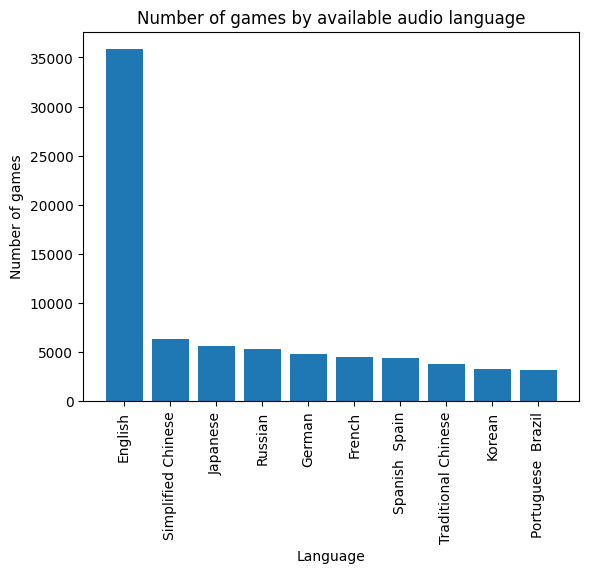

In [40]:
make_barplot(
    "full_audio_languages", df, "Language", "available audio language", rotation=True
)

**Both the text and audio of the games are mostly in English**

### Windows, Mac, Linux

In [41]:
print("Number of games available for")
for i in ["windows", "mac", "linux"]:
    print(f"{i}: {df[i].sum()}")

Number of games available for
windows: 89588
mac: 17438
linux: 12627


**We see that mostly games are released for windows**

### Metacritic score

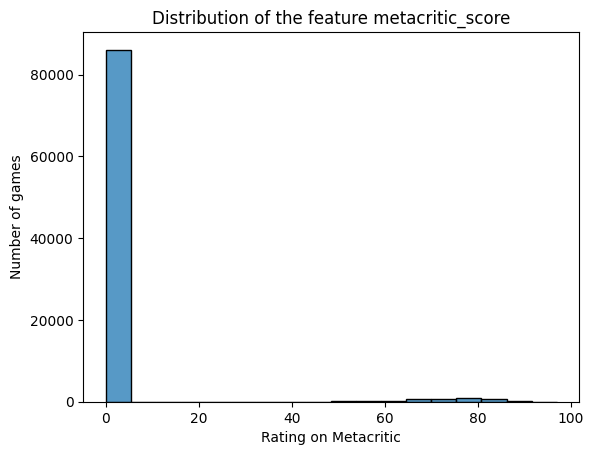

In [42]:
make_histplot("metacritic_score", df, "Rating on Metacritic")

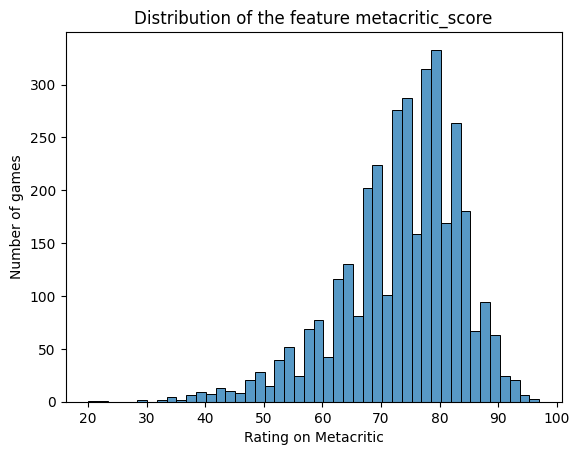

In [43]:
make_histplot(
    "metacritic_score", df[df["metacritic_score"] != 0], "Rating on Metacritic"
)

**Metacritic score data is available for a small fraction of games. However, for those games that do have a score, the most common is around 65-85**

### Positive, Negative

In [44]:
for feature in ["positive", "negative"]:
    print(f"Number of {feature} reviews: {df[feature].sum()}")

Number of positive reviews: 113805538
Number of negative reviews: 18802085


### Achievements

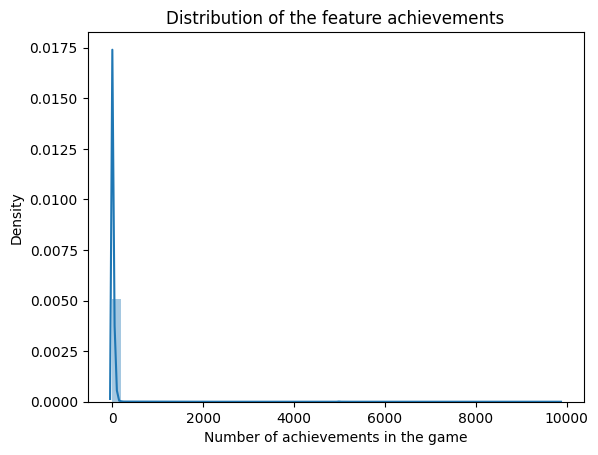

In [45]:
make_distplot("achievements", df, "Number of achievements in the game")

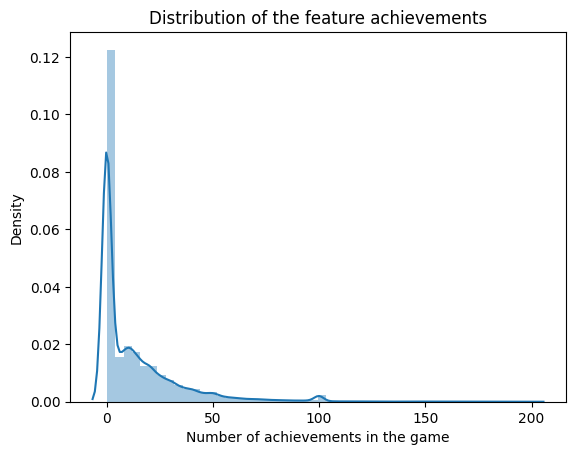

In [46]:
make_distplot(
    "achievements", df[df["achievements"] < 200], "Number of achievements in the game"
)

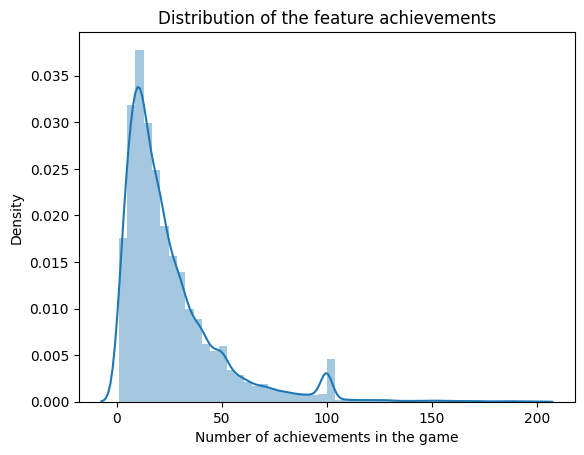

In [47]:
make_distplot(
    "achievements",
    df[(df["achievements"] != 0) & (df["achievements"] < 200)],
    "Number of achievements in the game",
)

**Most games with achievements have few (less than 15)**

### Playtime

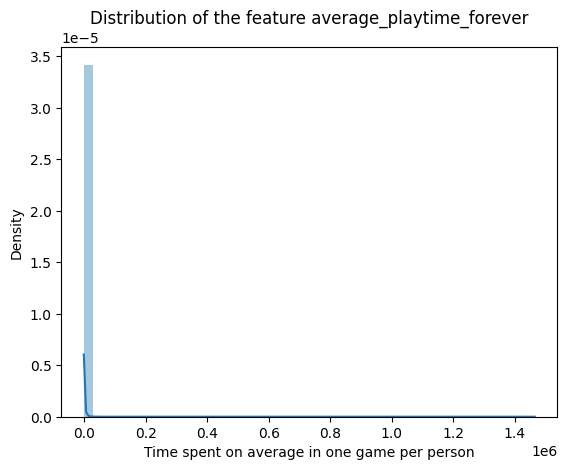

In [48]:
make_distplot(
    "average_playtime_forever", df, "Time spent on average in one game per person"
)

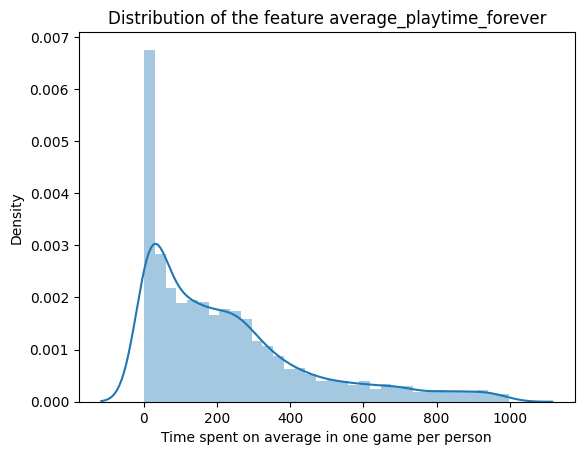

In [49]:
make_distplot(
    "average_playtime_forever",
    df[(df["average_playtime_forever"] != 0) & (df["average_playtime_forever"] < 1000)],
    "Time spent on average in one game per person",
)

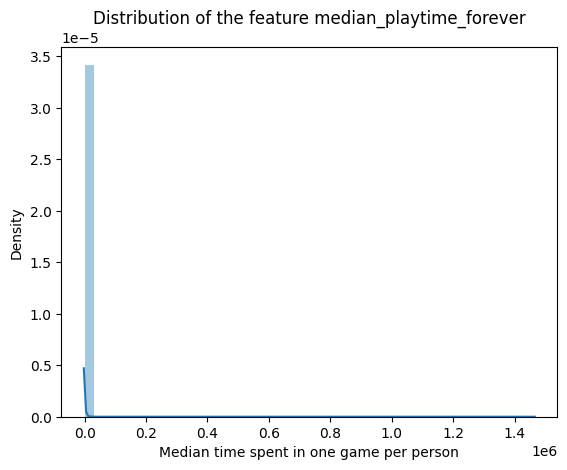

In [50]:
make_distplot("median_playtime_forever", df, "Median time spent in one game per person")

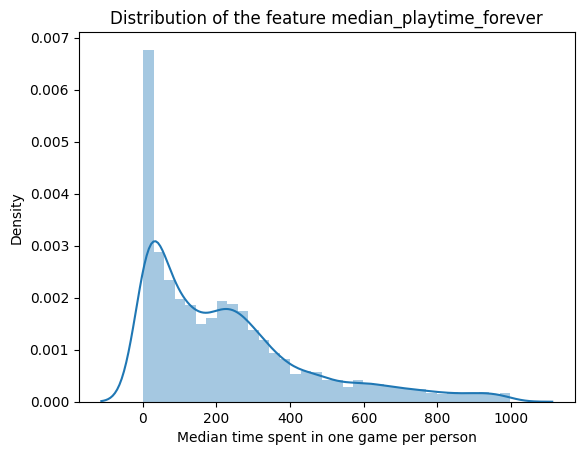

In [51]:
make_distplot(
    "median_playtime_forever",
    df[(df["median_playtime_forever"] != 0) & (df["median_playtime_forever"] < 1000)],
    "Median time spent in one game per person",
)

### Notes

In [52]:
df["notes_type"] = [get_notes_type(note) for note in df["notes"]]

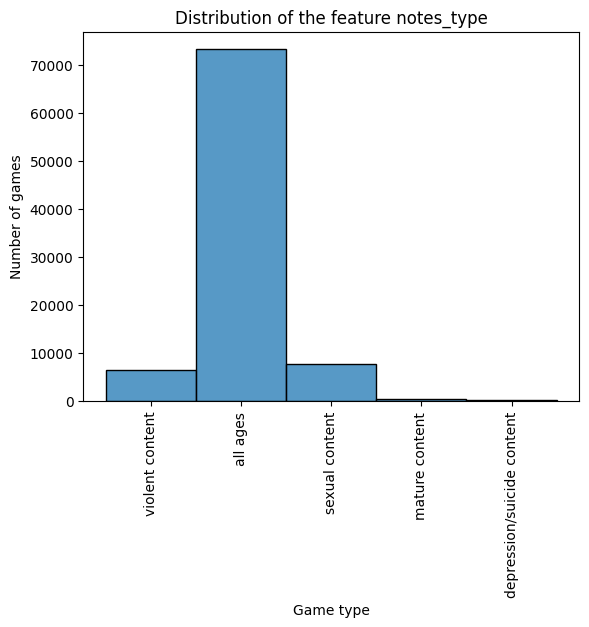

In [53]:
make_histplot("notes_type", df, "Game type", rotation=True)

**Mainly games for all ages are represented**

### Developers

In [54]:
df, sorted_categories_df = make_set("developers", "developers_set", df)

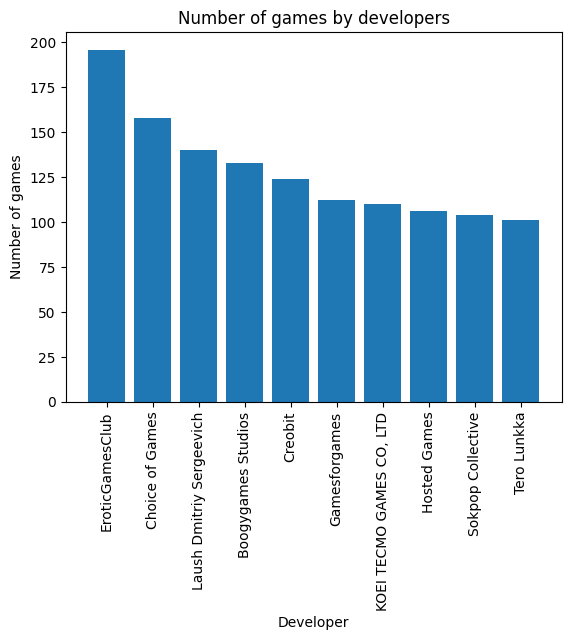

In [55]:
make_barplot("developers_set", df, "Developer", "developers", rotation=True)

### Publishers

In [56]:
df, sorted_categories_df = make_set("publishers", "publishers_set", df)

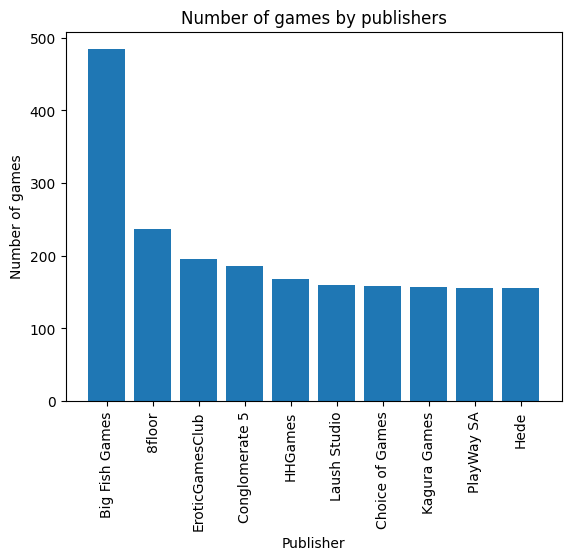

In [57]:
make_barplot("publishers_set", df, "Publisher", "publishers", rotation=True)

### Categories

In [58]:
df, sorted_categories_df = make_set("categories", "categories_set", df)

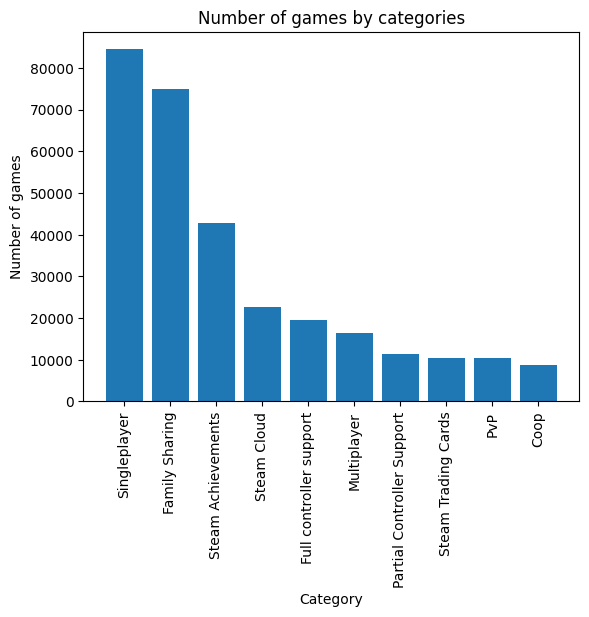

In [59]:
make_barplot("categories_set", df, "Category", "categories", rotation=True)

### Genres

In [60]:
df, sorted_genres_df = make_set("genres", "genres_set", df)

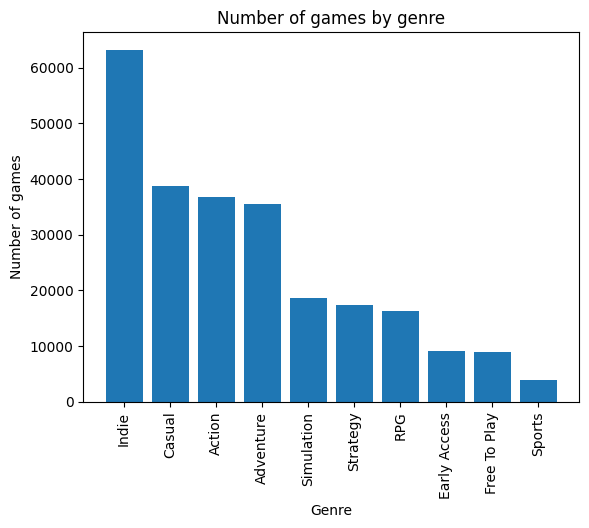

In [61]:
make_barplot("genres_set", df, "Genre", "genre", rotation=True)

### Tags

In [62]:
df, sorted_tags_df = make_set("tags", "tags_set", df)

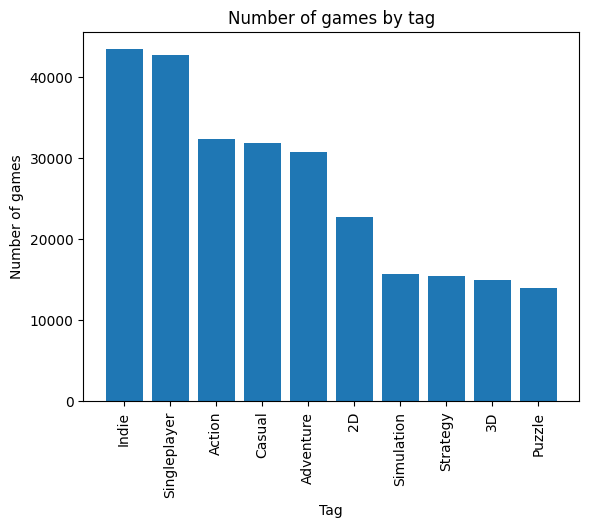

In [63]:
make_barplot("tags_set", df, "Tag", "tag", rotation=True)

**Mainly indie games without multiplayer are represented in the sample**

# Multivariate analysis

In [64]:
df["categories_set"]

0        {Valve AntiCheat enabled, InApp Purchases, Cro...
1        {PvP, Multiplayer, Remote Play on Tablet, Stat...
2        {Coop, SteamVR Collectibles, Valve AntiCheat e...
3        {PvP, Coop, Steam Achievements, Singleplayer, ...
4        {PvP, Coop, InApp Purchases, Singleplayer, Ful...
                               ...                        
89613    {Steam Achievements, Singleplayer, Family Shar...
89614                       {Singleplayer, Family Sharing}
89615                       {Singleplayer, Family Sharing}
89616    {PvP, Coop, Steam Achievements, Singleplayer, ...
89617    {PvP, Coop, Steam Achievements, Singleplayer, ...
Name: categories_set, Length: 89618, dtype: object

In [65]:
df["tag_indie"] = df["tags_set"].apply(lambda x: "indie" in str(x).lower())

df["tag_singleplayer"] = df["tags_set"].apply(
    lambda x: "singleplayer" in str(x).lower()
)
df["category_singleplayer"] = df["categories_set"].apply(
    lambda x: "singleplayer" in str(x).lower()
)

df["genre_indie"] = df["genres_set"].apply(lambda x: "indie" in str(x).lower())
df["genre_casual"] = df["genres_set"].apply(lambda x: "casual" in str(x).lower())
df["genre_action"] = df["genres_set"].apply(lambda x: "action" in str(x).lower())
df["genre_adventure"] = df["genres_set"].apply(lambda x: "adventure" in str(x).lower())
df["genre_simulation"] = df["genres_set"].apply(
    lambda x: "simulation" in str(x).lower()
)

In [66]:
df_estown_price = df[
    (df["price_group"].isin(["Free", "< 5$", "< 10$", "< 15$", "< 20$", "< 25$"]))
    & (
        df["estimated_owners"].isin(
            [
                "0 - 0",
                "0 - 20000",
                "20000 - 50000",
                "50000 - 100000",
                "100000 - 200000",
                "200000 - 500000",
            ]
        )
    )
]

## Estimated owners

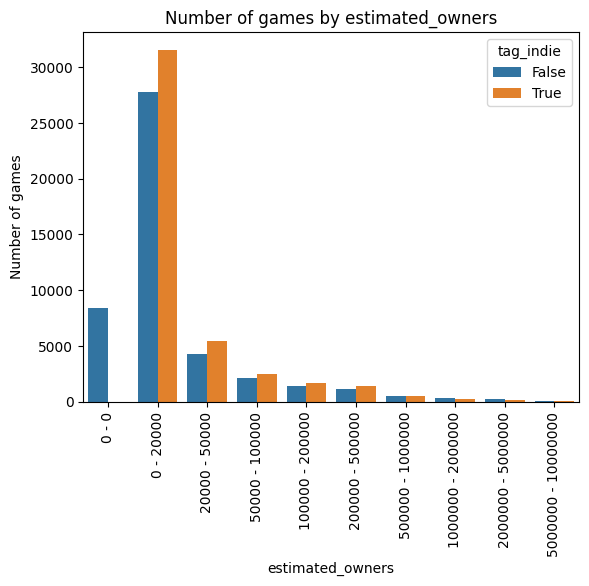

In [67]:
countplot_many_features(
    df,
    "estimated_owners",
    "tag_indie",
    sort_range(df["estimated_owners"])[:10],
    rotation=True,
)

**We see that games with an expected very small number of players are less likely to be labeled as indie**

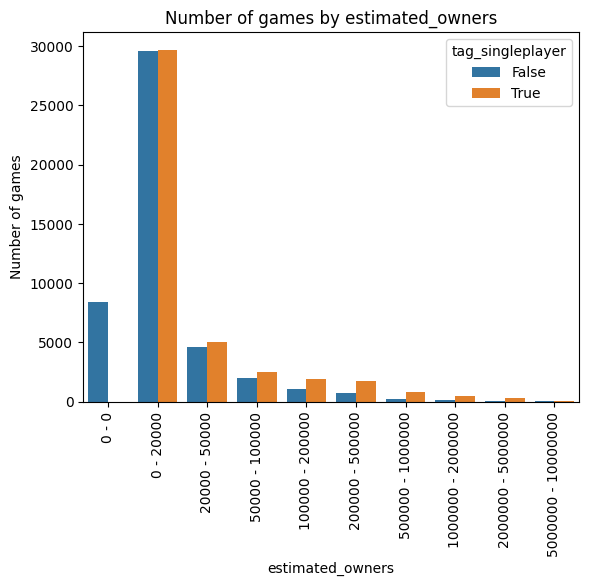

In [68]:
countplot_many_features(
    df,
    "estimated_owners",
    "tag_singleplayer",
    sort_range(df["estimated_owners"])[:10],
    rotation=True,
)

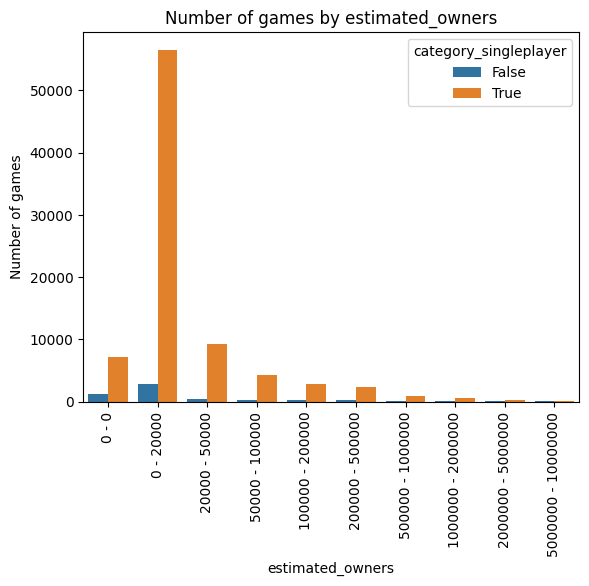

In [69]:
countplot_many_features(
    df,
    "estimated_owners",
    "category_singleplayer",
    sort_range(df["estimated_owners"])[:10],
    rotation=True,
)

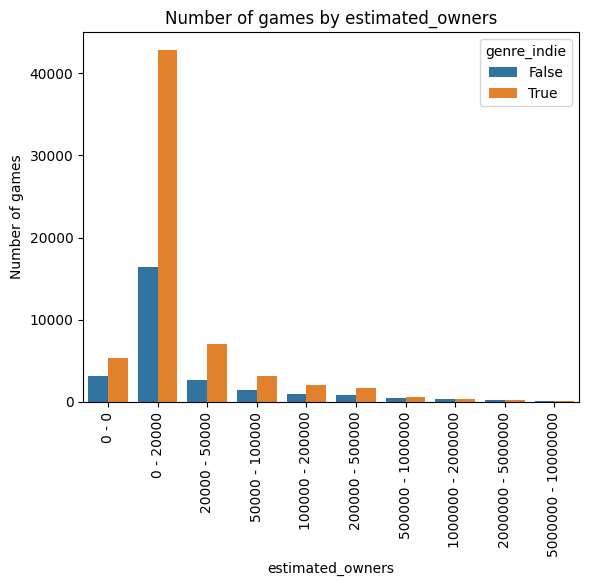

In [70]:
countplot_many_features(
    df,
    "estimated_owners",
    "genre_indie",
    sort_range(df["estimated_owners"])[:10],
    rotation=True,
)

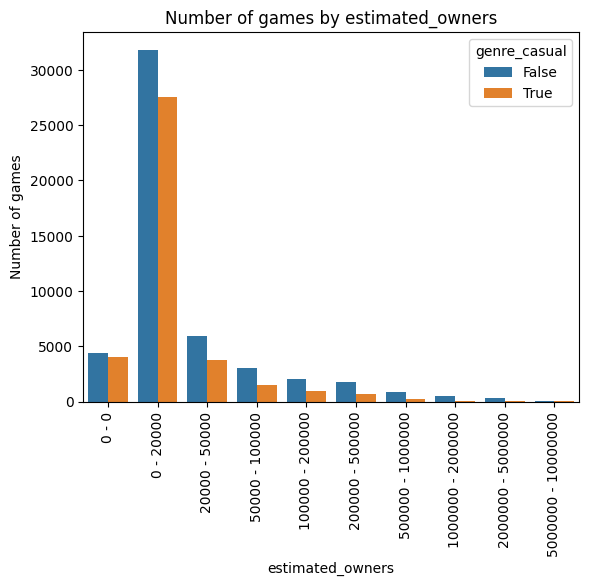

In [71]:
countplot_many_features(
    df,
    "estimated_owners",
    "genre_casual",
    sort_range(df["estimated_owners"])[:10],
    rotation=True,
)

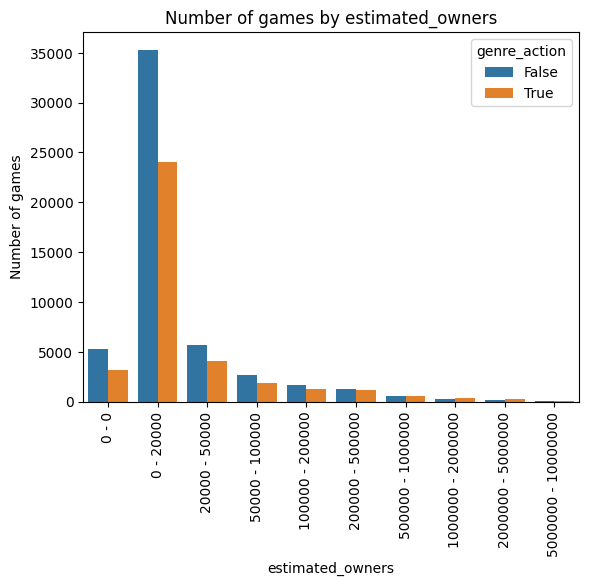

In [72]:
countplot_many_features(
    df,
    "estimated_owners",
    "genre_action",
    sort_range(df["estimated_owners"])[:10],
    rotation=True,
)

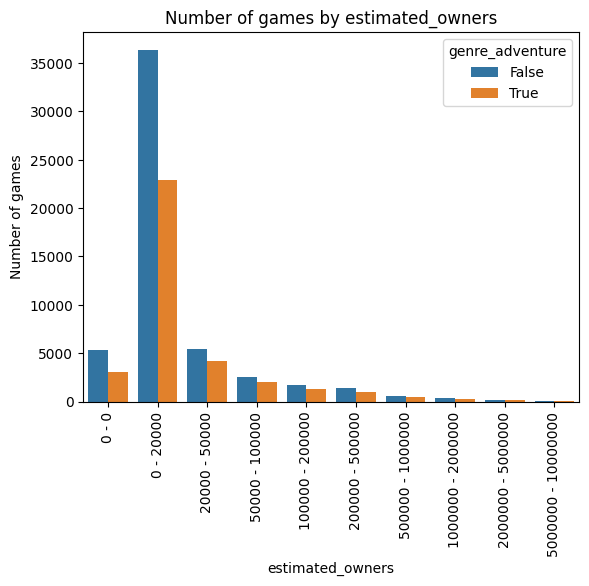

In [73]:
countplot_many_features(
    df,
    "estimated_owners",
    "genre_adventure",
    sort_range(df["estimated_owners"])[:10],
    rotation=True,
)

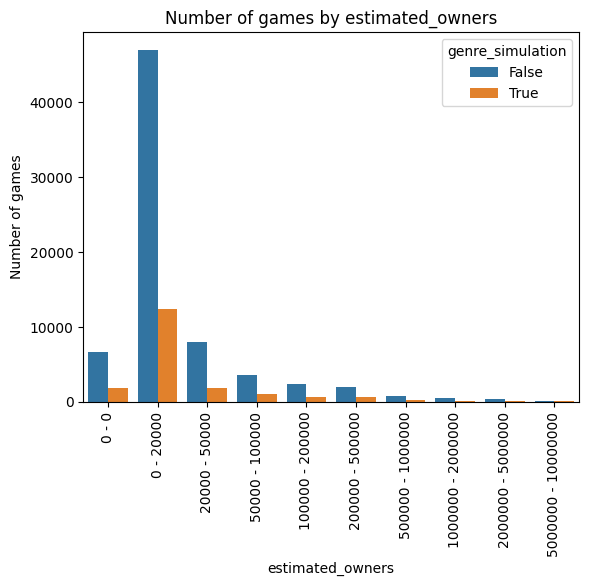

In [74]:
countplot_many_features(
    df,
    "estimated_owners",
    "genre_simulation",
    sort_range(df["estimated_owners"])[:10],
    rotation=True,
)

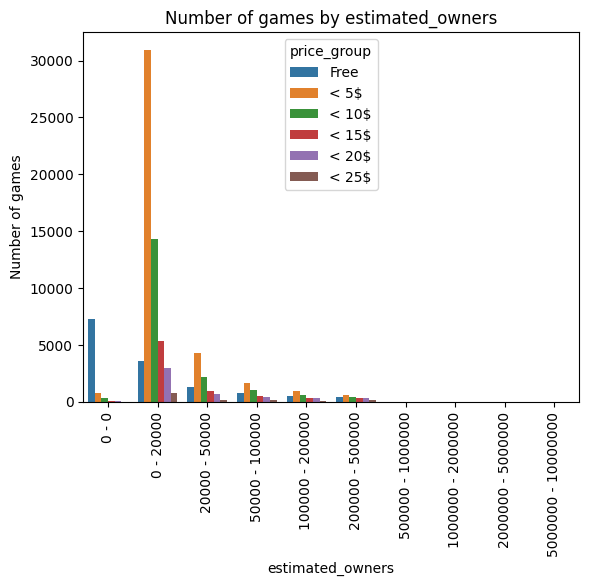

In [75]:
hue_order = ("Free", "< 5$", "< 10$", "< 15$", "< 20$", "< 25$")

feature = "estimated_owners"
sns.countplot(
    data=df_estown_price,
    x=feature,
    hue="price_group",
    order=sort_range(df["estimated_owners"])[:10],
    hue_order=hue_order,
)
plt.xticks(rotation=90)
plt.xlabel(feature)
plt.ylabel("Number of games")
plt.title(f"Number of games by {feature}")
plt.show()

**We see that for free games the expected number of players is very low**

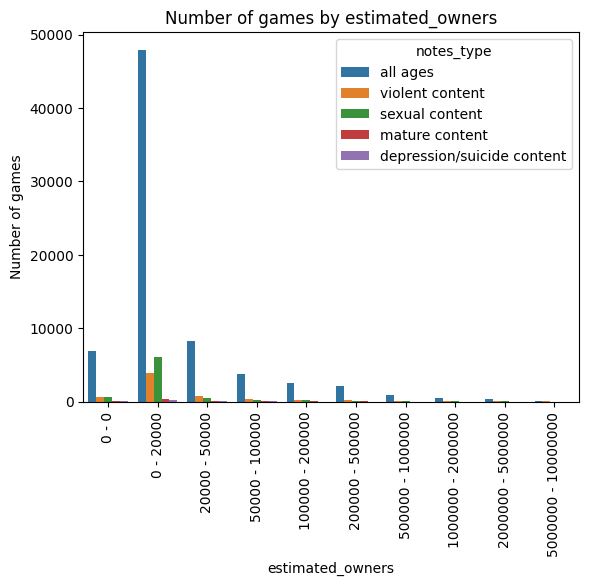

In [76]:
countplot_many_features(
    df,
    "estimated_owners",
    "notes_type",
    sort_range(df["estimated_owners"])[:10],
    rotation=True,
)

## Price group

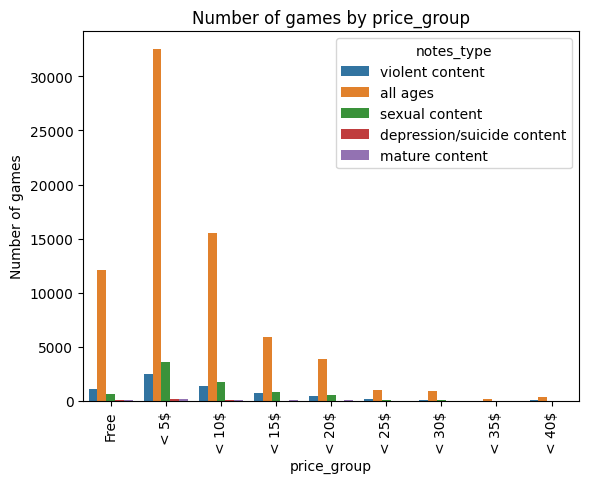

In [77]:
countplot_many_features(
    df, "price_group", "notes_type", sort_prices(df["price_group"])[:9], rotation=True
)

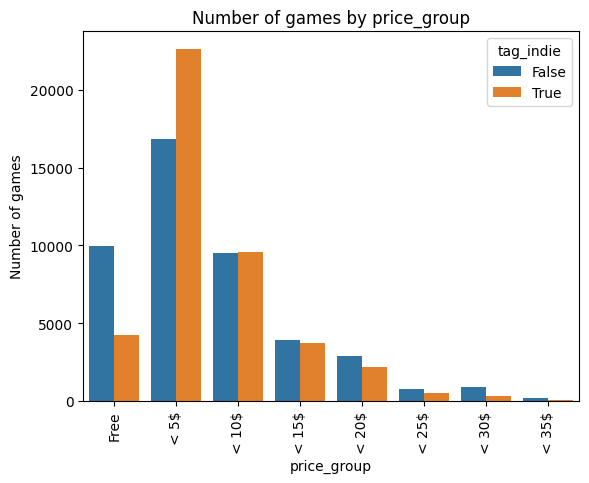

In [78]:
countplot_many_features(
    df, "price_group", "tag_indie", sort_prices(df["price_group"])[:8], rotation=True
)

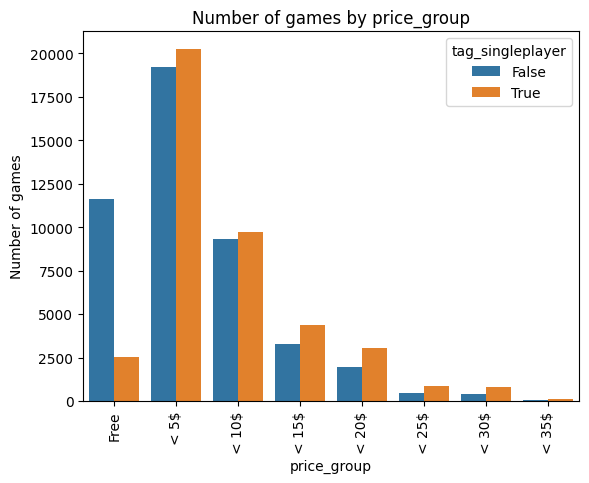

In [79]:
countplot_many_features(
    df,
    "price_group",
    "tag_singleplayer",
    sort_prices(df["price_group"])[:8],
    rotation=True,
)

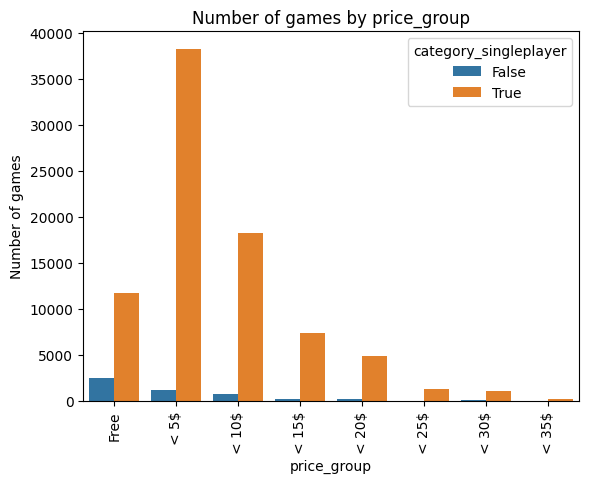

In [80]:
countplot_many_features(
    df,
    "price_group",
    "category_singleplayer",
    sort_prices(df["price_group"])[:8],
    rotation=True,
)

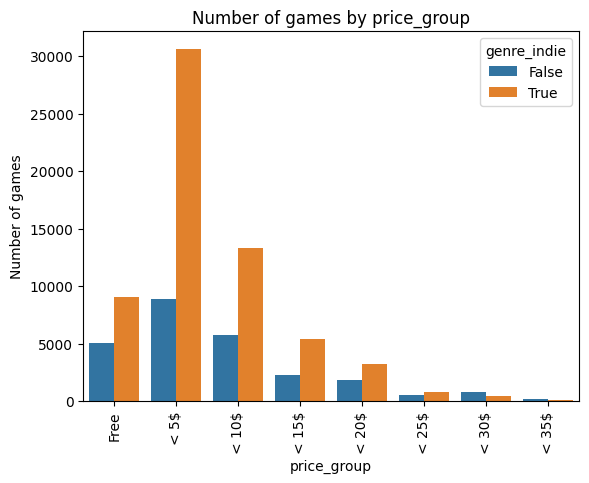

In [81]:
countplot_many_features(
    df, "price_group", "genre_indie", sort_prices(df["price_group"])[:8], rotation=True
)

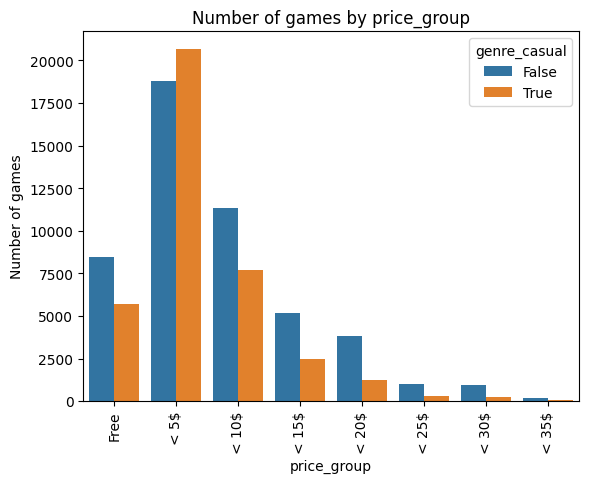

In [82]:
countplot_many_features(
    df, "price_group", "genre_casual", sort_prices(df["price_group"])[:8], rotation=True
)

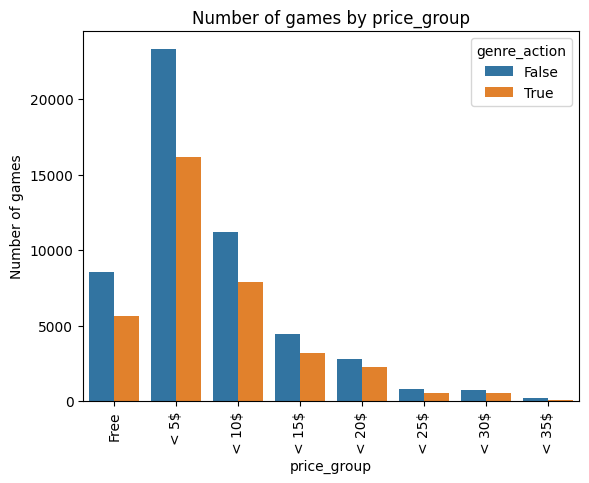

In [83]:
countplot_many_features(
    df, "price_group", "genre_action", sort_prices(df["price_group"])[:8], rotation=True
)

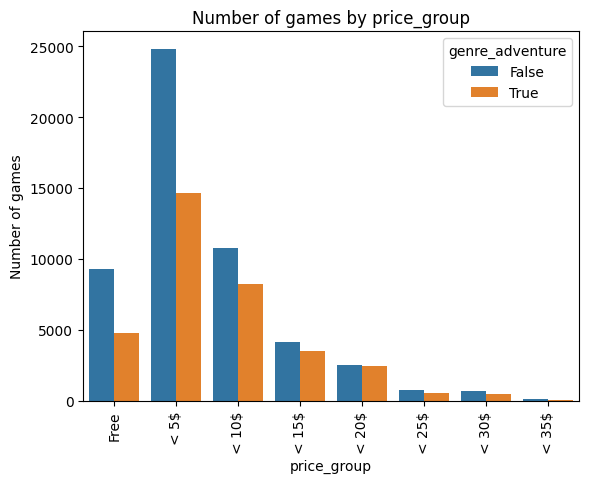

In [84]:
countplot_many_features(
    df,
    "price_group",
    "genre_adventure",
    sort_prices(df["price_group"])[:8],
    rotation=True,
)

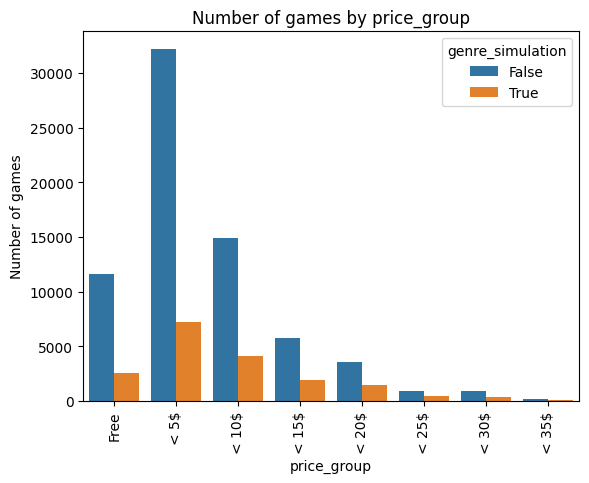

In [85]:
countplot_many_features(
    df,
    "price_group",
    "genre_simulation",
    sort_prices(df["price_group"])[:8],
    rotation=True,
)

# Correlation analysis

In [86]:
df

,appid,name,release_date,required_age,price,dlc_count,detailed_description,about_the_game,short_description,reviews,windows,mac,linux,metacritic_score,achievements,recommendations,notes,supported_languages,full_audio_languages,packages,developers,publishers,categories,genres,positive,negative,estimated_owners,average_playtime_forever,median_playtime_forever,discount,tags,pct_pos_total,num_reviews_total,pct_pos_recent,num_reviews_recent,price_group,num_supported_languages,text_languages_set,num_full_audio_languages,audio_languages_set,notes_type,developers_set,publishers_set,categories_set,genres_set,tags_set,tag_indie,tag_singleplayer,category_singleplayer,genre_indie,genre_casual,genre_action,genre_adventure,genre_simulation
0,730,Counter-Strike 2,2012-08-21,0,0.00,1,"For over two decades, Counter-Strike has offer...","For over two decades, Counter-Strike has offer...","For over two decades, Counter-Strike has offer...",NaN,True,False,True,0,1,4401572,Includes intense violence and blood.,"[Czech, Danish, Dutch, English, Finnish, Frenc...","[English, Indonesian]","[{'title': 'Buy Counter-Strike 2', 'descriptio...",[Valve],[Valve],"[Multiplayer, CrossPlatform Multiplayer, Steam...","[Action, Free To Play]",7480813,1135108,100000000 - 200000000,33189,5174,0,"[FPS, Shooter, Multiplayer, Competitive, Actio...",86,8632939,82,96473,Free,29,"{Finnish, Dutch, Ukrainian, Danish, Thai, Indo...",2,"{Indonesian, English}",violent content,{Valve},{Valve},"{Valve AntiCheat enabled, InApp Purchases, Cro...","{Free To Play, Action}","{FPS, Team-Based, Tactical, OnlineCo-Op, Compe...",False,False,False,False,False,True,False,False
1,578080,PUBG: BATTLEGROUNDS,2017-12-21,0,0.00,0,"LAND, LOOT, SURVIVE! Play PUBG: BATTLEGROUNDS ...","LAND, LOOT, SURVIVE! Play PUBG: BATTLEGROUNDS ...",Play PUBG: BATTLEGROUNDS for free. Land on str...,NaN,True,False,False,0,37,1732007,NaN,"[English, Korean, Simplified Chinese, French, ...",[],[],[PUBG Corporation],"[KRAFTON, Inc]","[Multiplayer, PvP, Online PvP, Stats, Remote P...","[Action, Adventure, Massively Multiplayer, Fre...",1487960,1024436,50000000 - 100000000,0,0,0,"[Survival, Shooter, BattleRoyale, Multiplayer,...",59,2513842,68,16720,Free,17,"{Spanish Spain, French, Turkish, Traditional ...",1,{},all ages,{PUBG Corporation},"{KRAFTON, Inc}","{PvP, Multiplayer, Remote Play on Tablet, Stat...","{Free To Play, Action, Adventure, Massively Mu...","{FPS, Team-Based, Tactical, Simulation, Online...",False,False,False,False,False,True,True,False
2,570,Dota 2,2013-07-09,0,0.00,2,"The most-played game on Steam. Every day, mill...","The most-played game on Steam. Every day, mill...","Every day, millions of players worldwide enter...",“A modern multiplayer masterpiece.” 9.5/10 – D...,True,True,True,90,0,14337,"Dota 2 includes fantasy violence, use of alcoh...","[Bulgarian, Czech, Danish, Dutch, English, Fin...","[English, Korean, Simplified Chinese, Vietnamese]","[{'title': 'Buy Dota 2', 'description': '', 's...",[Valve],[Valve],"[Multiplayer, Coop, Steam Trading Cards, Steam...","[Action, Strategy, Free To Play]",1998462,451338,200000000 - 500000000,43031,898,0,"[FreetoPlay, MOBA, Multiplayer, Strategy, e-sp...",81,2452595,80,29366,Free,28,"{Finnish, Dutch, Ukrainian, Danish, Thai, Port...",4,"{Vietnamese, Korean, Simplified Chinese, English}",sexual content,{Valve},{Valve},"{Coop, SteamVR Collectibles, Valve AntiCheat e...","{Free To Play, Action, Strategy}","{Team-Based, Simulation, OnlineCo-Op, MOBA, Co...",False,False,False,False,False,True,False,False
3,271590,Grand Theft Auto V Legacy,2015-04-13,17,0.00,0,"When a young street hustler, a retired bank ro...","When a young street hustler, a retired bank ro...",Grand Theft Auto V for PC offers players the o...,NaN,True,False,False,96,77,1803063,NaN,"[English, French, Italian, German, Spanish Sp...","[English, Spanish Latin America]","[{'title': 'Buy Shark Cash Cards', 'descriptio...",[Rockstar North],[Rockstar Games],"[Singleplayer, Multiplayer, PvP, Online PvP

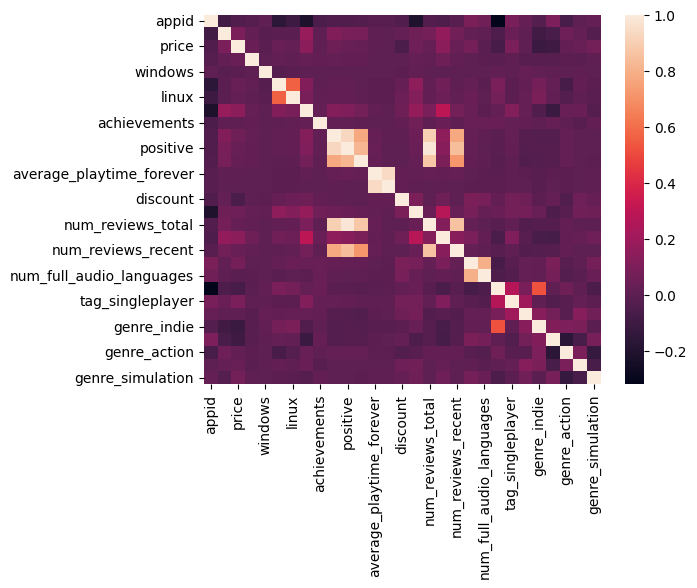

In [87]:
df_num = df.select_dtypes(include=["int", "float", "bool"])
corr_matrix = df_num.corr()
sns.heatmap(corr_matrix)
plt.show()

**There are correlated features:**
- Num Supported languages и Num Full audio languages
- Positive/Negative и Recommendations
- Average playtime (forever и two weeks)

### Let's plot the correlated features

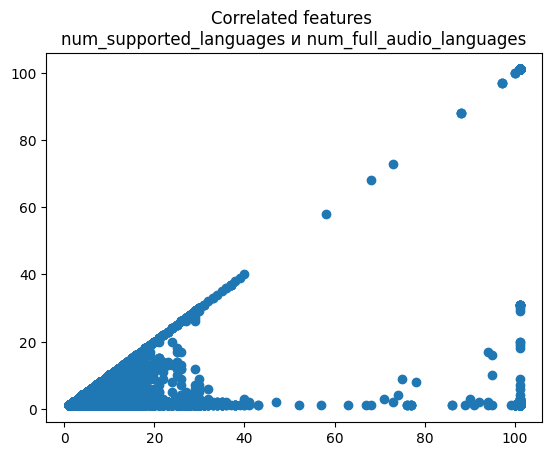

In [88]:
plot_correlated_features(df, "num_supported_languages", "num_full_audio_languages")

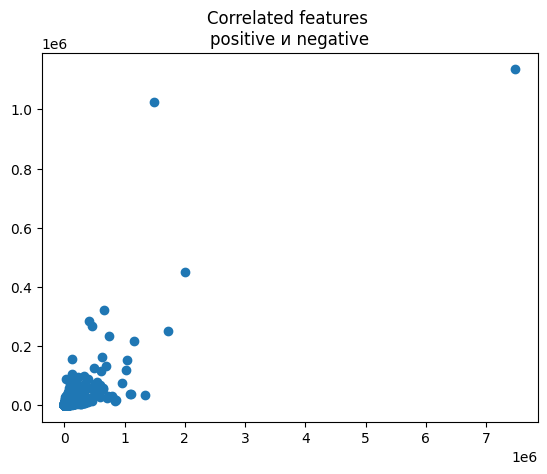

In [89]:
plot_correlated_features(df, "positive", "negative")

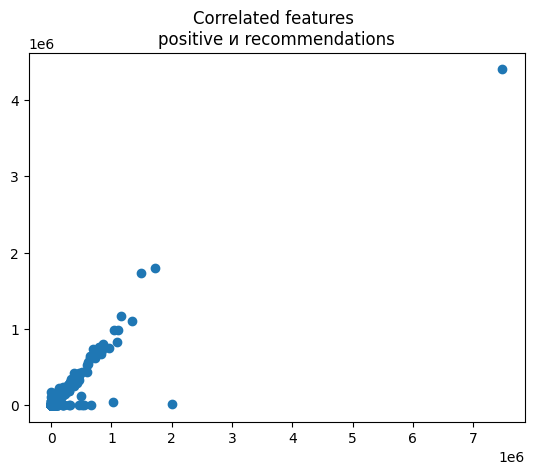

In [90]:
plot_correlated_features(df, "positive", "recommendations")

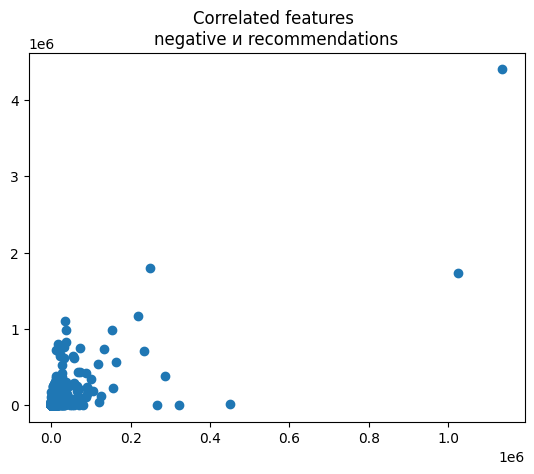

In [91]:
plot_correlated_features(df, "negative", "recommendations")

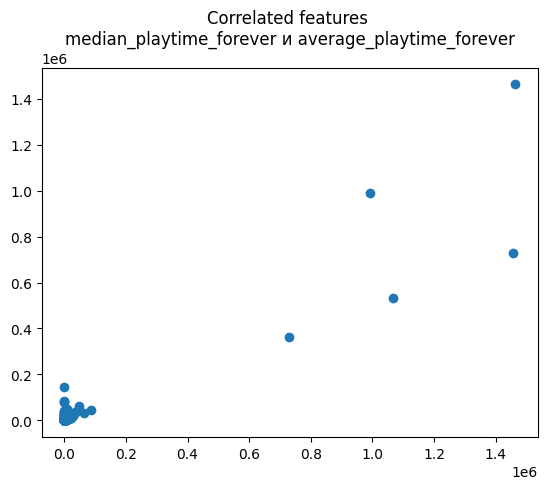

In [92]:
plot_correlated_features(df, "median_playtime_forever", "average_playtime_forever")

# Additional analysis when filtering out "thrash" games

In [93]:
df_popular_40 = df.query("num_reviews_total >= 40")
df_popular_50 = df.query("num_reviews_total >= 50")
df_popular_100 = df.query("num_reviews_total >= 100")

In [94]:
describe_perc(df)

,appid,required_age,price,dlc_count,metacritic_score,achievements,recommendations,positive,negative,average_playtime_forever,median_playtime_forever,discount,pct_pos_total,num_reviews_total,pct_pos_recent,num_reviews_recent,num_supported_languages,num_full_audio_languages
count,8.961800e+04,89618.000000,89618.000000,89618.000000,89618.000000,89618.000000,8.961800e+04,8.961800e+04,8.961800e+04,8.961800e+04,8.961800e+04,89618.000000,89618.000000,8.961800e+04,89618.000000,89618.000000,89618.000000,89618.000000
mean,1.656904e+06,0.183624,7.309623,0.595583,2.903245,20.552333,1.009401e+03,1.269896e+03,2.098026e+02,1.149119e+02,1.147559e+02,4.558627,45.352418,1.315490e+03,5.231639,15.584581,5.210828,2.617052
std,9.168390e+05,1.725594,13.331073,15.351920,14.445358,163.562418,2.204815e+04,3.181441e+04,6.114314e+03,6.814748e+03,8.806711e+03,16.538036,40.685695,3.542370e+04,22.335358,444.277307,13.045011,10.641234
min,2.000000e+01,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,-1.000000,-1.000000e+00,-1.000000,-1.000000,1.000000,1.000000
1%,2.226719e+05,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,-1.000000,-1.000000e+00,-1.000000,-1.000000,1.000000,1.000000
5%,3.550585e+05,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,-1.000000,-1.000000e+00,-1.000000,-1.000000,1.000000,1.000000
10%,4.880770e+05,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,-1.000000,-1.000000e+00,-1.000000,-1.000000,1.000000,1.000000
25%,8.550525e+05,0.000000,0.990000,0.000000,0.000000,0.000000,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,-1.000000,-1.000000e+00,-1.000000,-1.000000,1.000000,1.000000
50%,1.524730e+06,0.000000,4.990000,0.000000,0.000000,5.000000,0.000000e+00,1.000000e+01,2.000000e+00,0.000000e+00,0.000000e+00,0.000000,60.000000,1.500000e+01,-1.000000,-1.000000,1.000000,1.000000
75%,2.430852e+06,0.000000,9.990000,0.000000,0.000000,20.000000,0.000000e+00,5.800000e+01,1.700000e+01,0.000000e+00,0.000000e+00,0.000000,84.000000,8.100000e+01,-1.000000,-1.000000,4.000000,1.000000


In [95]:
describe_perc(df_popular_40)

,appid,required_age,price,dlc_count,metacritic_score,achievements,recommendations,positive,negative,average_playtime_forever,median_playtime_forever,discount,pct_pos_total,num_reviews_total,pct_pos_recent,num_reviews_recent,num_supported_languages,num_full_audio_languages
count,3.054700e+04,30547.000000,30547.000000,30547.000000,30547.000000,30547.000000,3.054700e+04,3.054700e+04,3.054700e+04,3.054700e+04,3.054700e+04,30547.000000,30547.000000,3.054700e+04,30547.000000,30547.000000,30547.000000,30547.000000
mean,1.291352e+06,0.418241,9.242927,1.342423,8.175664,40.529872,2.925829e+03,3.664079e+03,6.055977e+02,3.241166e+02,3.236258e+02,6.702819,78.589059,3.845475e+03,16.853210,46.833764,6.548368,2.861099
std,8.506762e+05,2.593505,10.697254,25.037416,23.394410,272.856714,3.740248e+04,5.418845e+04,1.046085e+04,1.165911e+04,1.507452e+04,19.789737,15.143049,6.059522e+04,34.943837,757.439071,12.269768,10.373676
min,2.000000e+01,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,1.000000,4.000000e+01,-1.000000,-1.000000,1.000000,1.000000
1%,6.553460e+04,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,33.000000,4.000000e+01,-1.000000,-1.000000,1.000000,1.000000
5%,2.634320e+05,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,49.000000,4.500000e+01,-1.000000,-1.000000,1.000000,1.000000
10%,3.322300e+05,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,57.000000,5.100000e+01,-1.000000,-1.000000,1.000000,1.000000
25%,5.542850e+05,0.000000,0.990000,0.000000,0.000000,0.000000,0.000000e+00,4.900000e+01,8.000000e+00,0.000000e+00,0.000000e+00,0.000000,70.000000,7.700000e+01,-1.000000,-1.000000,1.000000,1.000000
50%,1.141650e+06,0.000000,5.990000,0.000000,0.000000,15.000000,1.190000e+02,1.330000e+02,3.400000e+01,0.000000e+00,0.000000e+00,0.000000,82.000000,1.800000e+02,-1.000000,-1.000000,3.000000,1.000000
75%,1.919525e+06,0.000000,14.990000,1.000000,0.000000,33.000000,4.780000e+02,5.500000e+02,1.260000e+02,0.000000e+00,0.000000e+00,0.000000,90.000000,6.840000e+02,-1.000000,-1.000000,8.000000,2.000000


In [96]:
describe_perc(df_popular_50)

,appid,required_age,price,dlc_count,metacritic_score,achievements,recommendations,positive,negative,average_playtime_forever,median_playtime_forever,discount,pct_pos_total,num_reviews_total,pct_pos_recent,num_reviews_recent,num_supported_languages,num_full_audio_languages
count,2.775000e+04,27750.000000,27750.000000,27750.000000,27750.000000,27750.000000,2.775000e+04,2.775000e+04,2.775000e+04,2.775000e+04,2.775000e+04,27750.000000,27750.000000,2.775000e+04,27750.000000,27750.000000,27750.000000,27750.000000
mean,1.268271e+06,0.453802,9.575937,1.444613,8.911351,42.648180,3.220732e+03,4.029616e+03,6.652958e+02,3.559574e+02,3.553689e+02,6.839351,78.957766,4.228609e+03,18.568360,51.638198,6.623712,2.816829
std,8.458807e+05,2.699426,10.882262,26.261671,24.298657,283.375156,3.923014e+04,5.684106e+04,1.097363e+04,1.223210e+04,1.581563e+04,19.968536,14.834611,6.356319e+04,36.118024,794.537503,12.026951,10.059476
min,2.000000e+01,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,1.000000,5.000000e+01,-1.000000,-1.000000,1.000000,1.000000
1%,6.305390e+04,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,34.000000,5.100000e+01,-1.000000,-1.000000,1.000000,1.000000
5%,2.578390e+05,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,50.000000,5.600000e+01,-1.000000,-1.000000,1.000000,1.000000
10%,3.230580e+05,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,58.000000,6.300000e+01,-1.000000,-1.000000,1.000000,1.000000
25%,5.378475e+05,0.000000,0.990000,0.000000,0.000000,0.000000,0.000000e+00,6.200000e+01,1.100000e+01,0.000000e+00,0.000000e+00,0.000000,71.000000,9.500000e+01,-1.000000,-1.000000,1.000000,1.000000
50%,1.120340e+06,0.000000,5.990000,0.000000,0.000000,15.000000,1.450000e+02,1.640000e+02,4.100000e+01,0.000000e+00,0.000000e+00,0.000000,82.000000,2.190000e+02,-1.000000,-1.000000,3.000000,1.000000
75%,1.889655e+06,0.000000,14.990000,1.000000,0.000000,34.000000,5.670000e+02,6.580000e+02,1.470000e+02,4.000000e+00,4.000000e+00,0.000000,90.000000,8.170000e+02,-1.000000,-1.000000,9.000000,2.000000


In [97]:
describe_perc(df_popular_100)

,appid,required_age,price,dlc_count,metacritic_score,achievements,recommendations,positive,negative,average_playtime_forever,median_playtime_forever,discount,pct_pos_total,num_reviews_total,pct_pos_recent,num_reviews_recent,num_supported_languages,num_full_audio_languages
count,2.038300e+04,20383.000000,20383.000000,20383.000000,20383.000000,20383.000000,2.038300e+04,2.038300e+04,2.038300e+04,2.038300e+04,2.038300e+04,20383.000000,20383.000000,2.038300e+04,20383.000000,20383.000000,20383.000000,20383.000000
mean,1.206985e+06,0.580042,10.616661,1.837953,11.440858,40.935436,4.384796e+03,5.463915e+03,8.978443e+02,4.753851e+02,4.719640e+02,7.260119,80.045234,5.731460e+03,24.902713,70.476819,6.923171,2.718000
std,8.271612e+05,3.038716,11.627179,30.619084,27.071952,238.016114,4.571835e+04,6.626423e+04,1.279606e+04,1.426682e+04,1.844162e+04,20.619891,14.096904,7.410881e+04,39.528080,926.350398,11.257723,8.993224
min,2.000000e+01,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,7.000000,1.000000e+02,-1.000000,-1.000000,1.000000,1.000000
1%,5.012460e+04,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,36.000000,1.020000e+02,-1.000000,-1.000000,1.000000,1.000000
5%,2.439520e+05,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,52.000000,1.110000e+02,-1.000000,-1.000000,1.000000,1.000000
10%,2.998140e+05,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,61.000000,1.240000e+02,-1.000000,-1.000000,1.000000,1.000000
25%,4.925150e+05,0.000000,0.990000,0.000000,0.000000,0.000000,1.190000e+02,1.270000e+02,2.200000e+01,0.000000e+00,0.000000e+00,0.000000,73.000000,1.800000e+02,-1.000000,-1.000000,1.000000,1.000000
50%,1.026680e+06,0.000000,7.990000,0.000000,0.000000,18.000000,2.750000e+02,3.090000e+02,7.300000e+01,0.000000e+00,0.000000e+00,0.000000,83.000000,3.980000e+02,-1.000000,-1.000000,4.000000,1.000000
75%,1.766080e+06,0.000000,14.990000,1.000000,0.000000,37.000000,1.000000e+03,1.184000e+03,2.390000e+02,7.500000e+01,6.800000e+01,0.000000,91.000000,1.427000e+03,72.000000,14.000000,9.000000,2.000000


**Conclusions:**
- Price - when adding any filter, the average price increases by 1.5 times
- Metacritic Score - when any filter is added, scores appear at the 90th percentile
- Average/Median Playtime Forever - signs were non-variable, after filtering they became more variable.

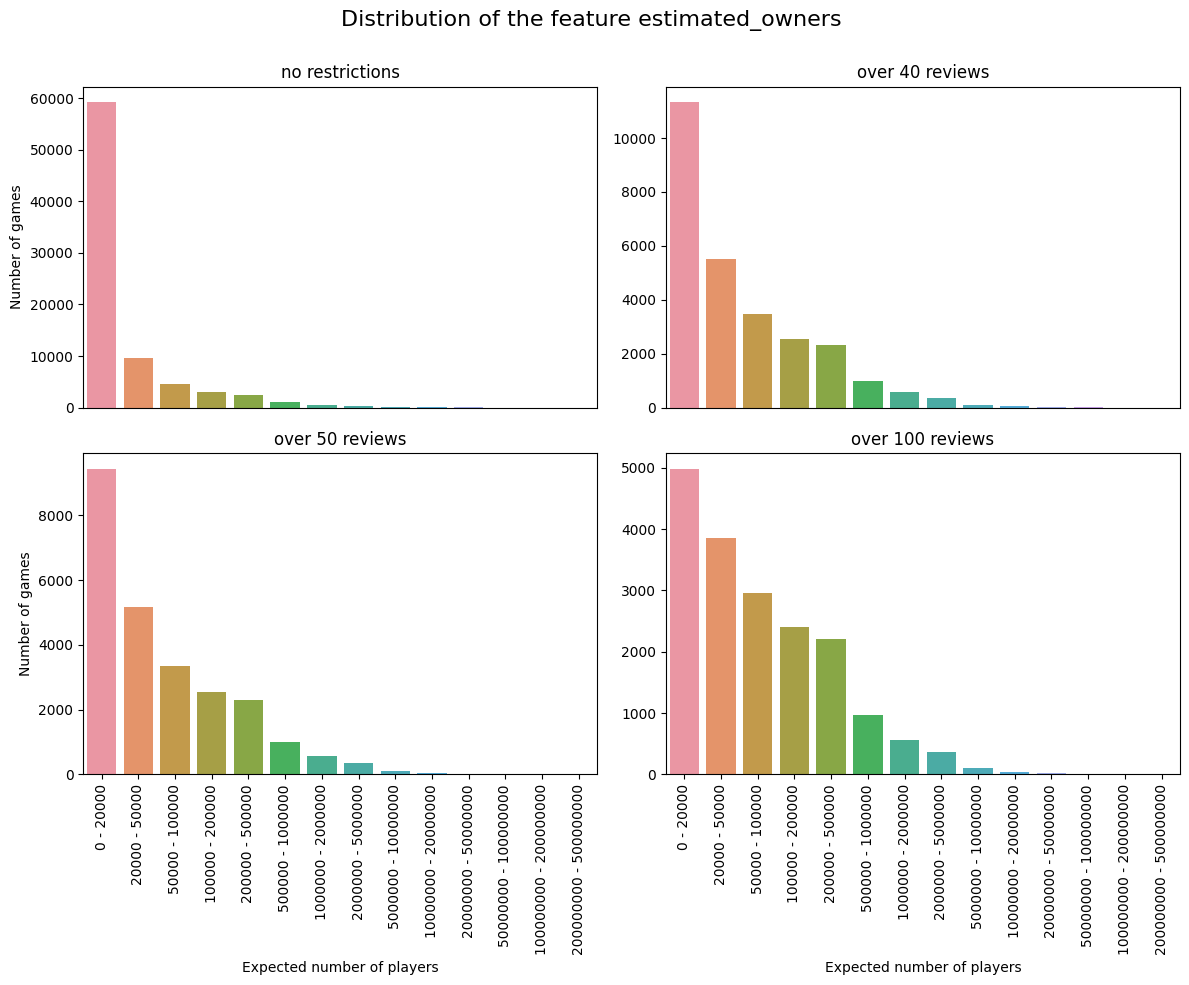

In [98]:
make_countplot_filtr(
    "estimated_owners",
    [df, df_popular_40, df_popular_50, df_popular_100],
    "Expected number of players",
    order=sort_range(df["estimated_owners"])[1:],
    rotation=True,
)

**We see that with filters on the number of reviews there are more games with a high expected number of players than without filters. This difference remains even with a less restrictive filter of >50 reviews**

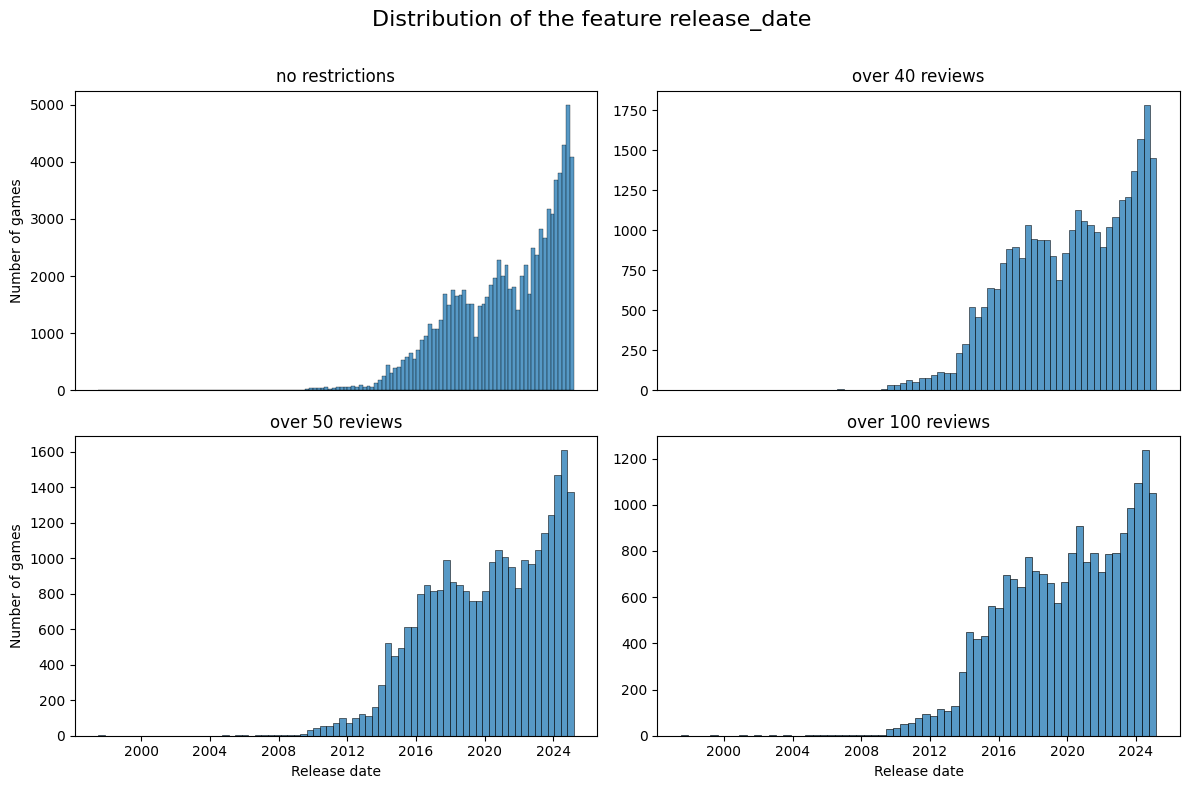

In [99]:
make_histplot_filtr(
    "release_date", [df, df_popular_40, df_popular_50, df_popular_100], "Release date"
)

**We see that with filters on the number of reviews there is a much larger share of old games and less of new ones than without filters. This difference remains even with a less restrictive filter of >50 reviews**

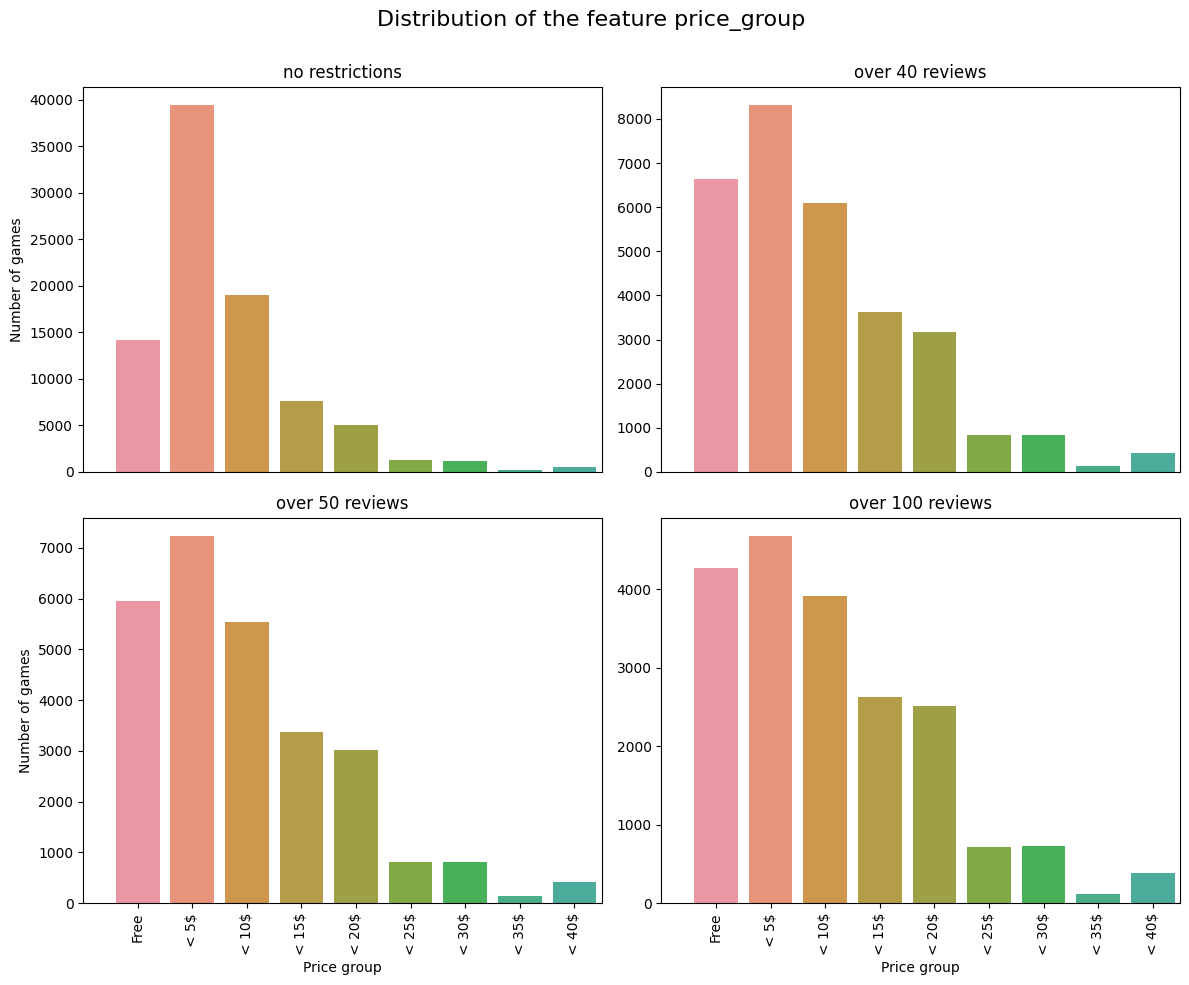

In [100]:
make_countplot_filtr(
    "price_group",
    [df, df_popular_40, df_popular_50, df_popular_100],
    "Price group",
    order=sort_prices(df["price_group"]),
    rotation=True,
    limit=8,
)

**We see that with filters on the number of reviews the share of expensive games is much higher than without filters. This difference remains even with a less restrictive filter of >50 reviews**

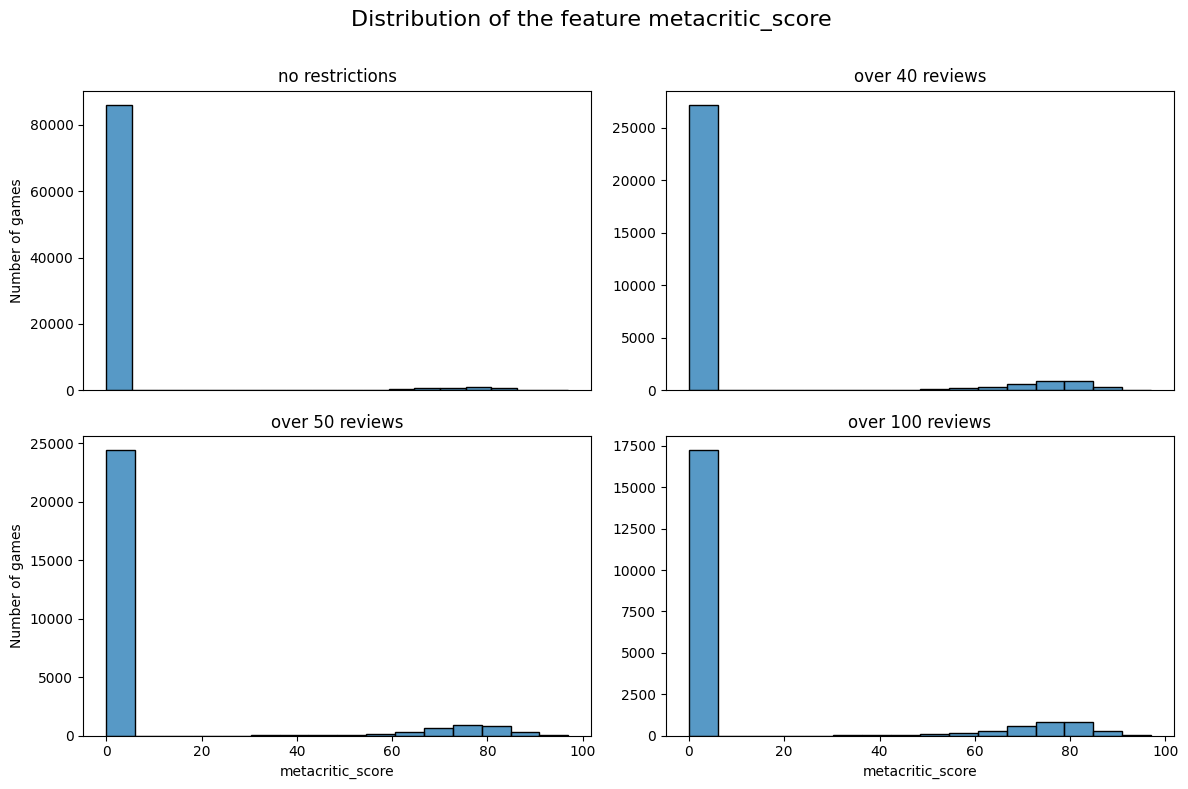

In [101]:
make_histplot_filtr(
    "metacritic_score",
    [df, df_popular_40, df_popular_50, df_popular_100],
    "metacritic_score",
)

**We see that with filters on the number of reviews there are much more games with metacritic scores than without filters. This difference remains even with a less restrictive filter of >50 reviews**

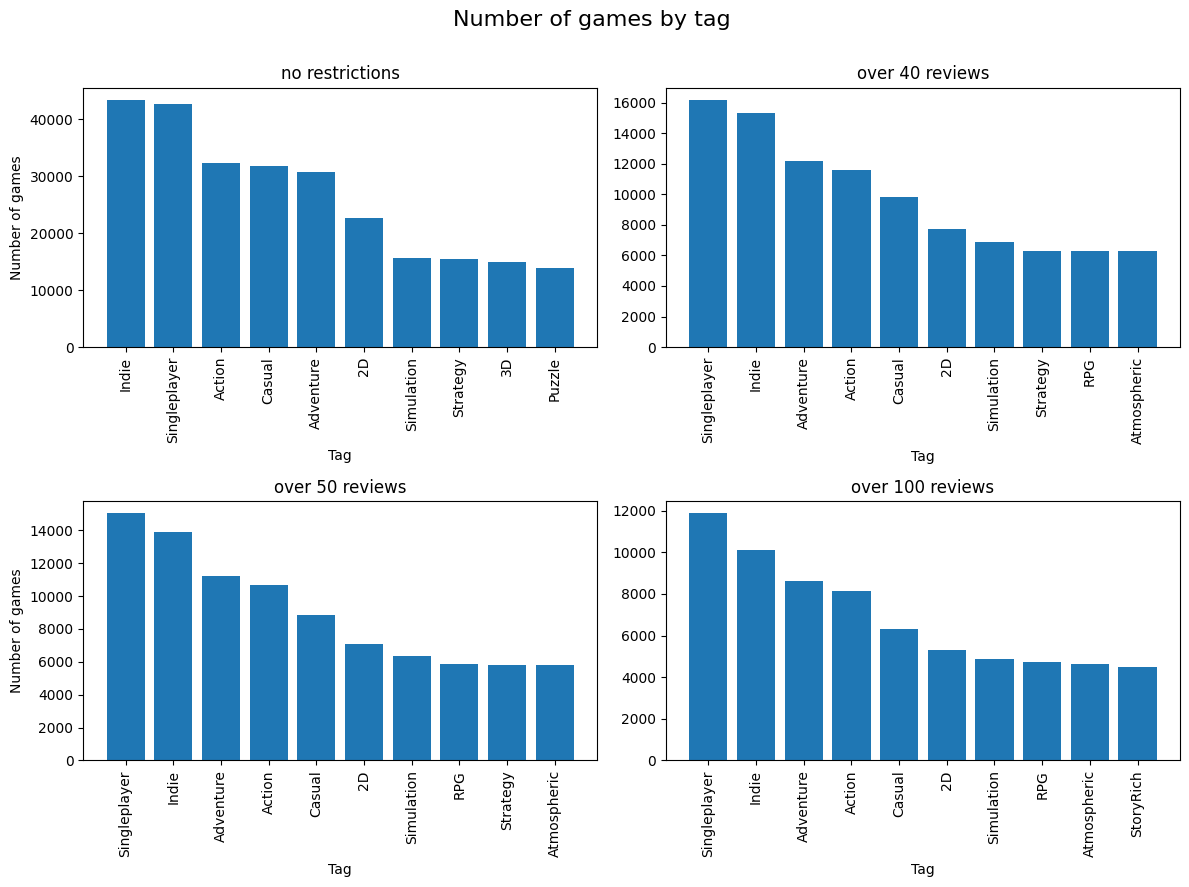

In [102]:
make_barplot_filtr(
    "tags_set",
    [df, df_popular_40, df_popular_50, df_popular_100],
    "Tag",
    "tag",
    rotation=True,
)

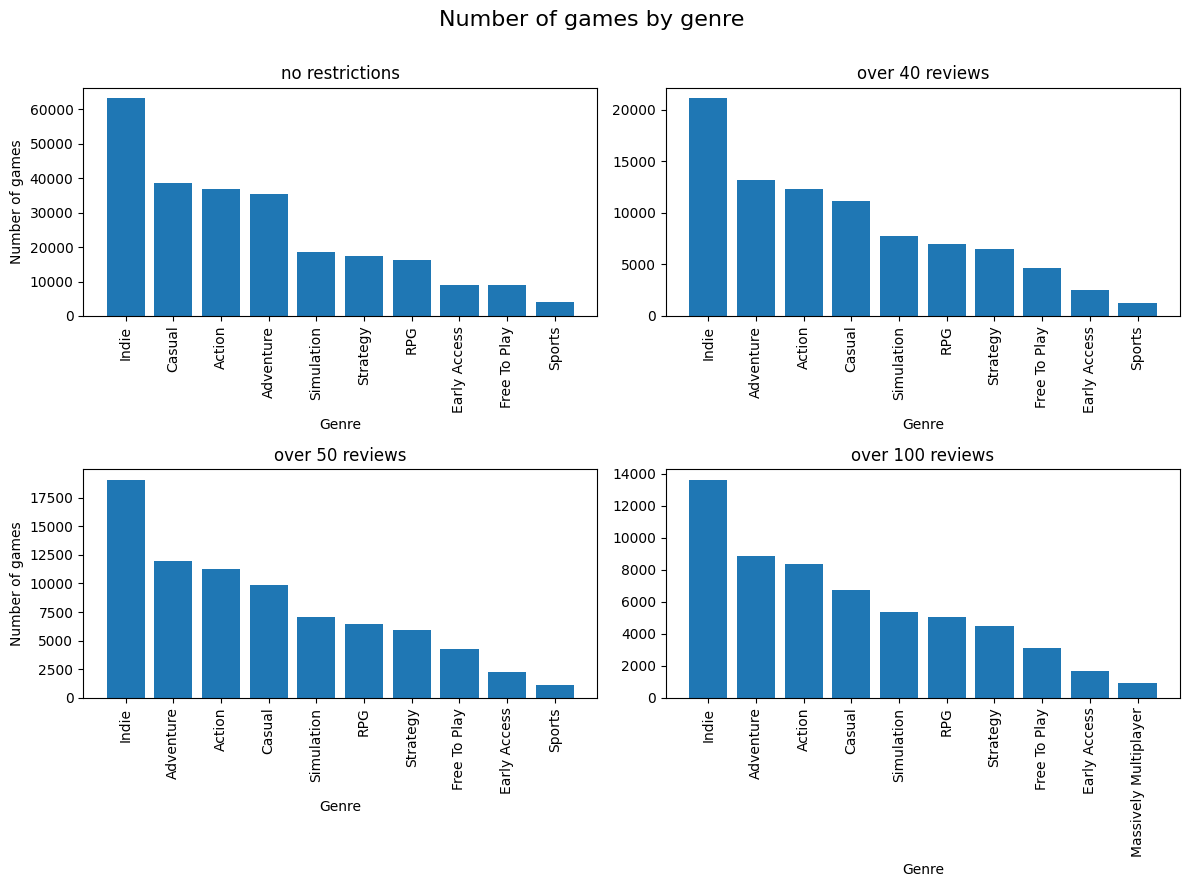

In [103]:
make_barplot_filtr(
    "genres_set",
    [df, df_popular_40, df_popular_50, df_popular_100],
    "Genre",
    "genre",
    rotation=True,
)

**We see that with any restriction the changes are insignificant, but the order of popular genres/tags etc. changes slightly**

In [104]:
len(df_popular_40)

30547

# CONCLUSIONS

1) Popular games in the dataset are about 28 thousand, the rest of the games are "trash": they have few reviews and the expected number of players for them is also small (even when using a filter of at least 50 reviews to determine popular games).

2) Popular games show different trends from the whole set of games (they have a higher price, higher expected number of players, they are older, they are dominated not only by the indie genre but also by action, they also have more user ratings on metacritic).  